In [ ]:
#Install all dependencies
!pip install torch torchvision torchaudio --index url https://download.pytorch.org/whl/cu118
!pip install diffusers==0.21.0 transformers==4.30.2 accelerate==0.20.3 safetensors==0.3.1 xformers==0.0.20 Pillow==9.5.0 numpy==1.24.4 matplotlib==3.7.2 gradio==4.0.0

Looking in indexes: url
  ERROR: Cannot unpack file /tmp/pip-unpack-3e0t_mxu/cu118.html (downloaded from /tmp/pip-req-build-6qrmfnz_, content-type: text/html); cannot detect archive format
ERROR: Cannot determine archive format of /tmp/pip-req-build-6qrmfnz_
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.6/113.6 kB 4.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 45.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 MB 21.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 120.7 MB/s 

In [ ]:
#imports and warning suppresion
import warnings
warnings.filterwarnings("ignore", message="A matching Trition is not available")

import torch
import torch.nn.functional as F
from torch import autocast
import numpy as np
from PIL import Image
import os
import time
import gc
from typing import Optional, Tuple, List
from datetime import datetime
from importlib.metadata import version

from diffusers import (
    StableDiffusionPipeline,
    EulerAncestralDiscreteScheduler,
    EulerDiscreteScheduler,
    DPMSolverMultistepScheduler,
    DDIMScheduler,
    LMSDiscreteScheduler,
    PNDMScheduler,
    UniPCMultistepScheduler,
)
import gradio as gr


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
# Imports and warning suppression
import warnings
warnings.filterwarnings("ignore", message="A matching Triton is not available")

import torch
import torch.nn.functional as F
from torch import autocast
import numpy as np
from PIL import Image
import os
import time
import gc
from typing import Optional, Tuple, List
from datetime import datetime
from importlib.metadata import version

from diffusers import (
    StableDiffusionPipeline,
    EulerAncestralDiscreteScheduler,
    EulerDiscreteScheduler,
    DPMSolverMultistepScheduler,
    DDIMScheduler,
    LMSDiscreteScheduler
)
import gradio as gr


# Core Stable Diffusion Generator class
class StableDiffusionGenerator:
    def __init__(self, model_id: str = "runwayml/stable-diffusion-v1-5", device: str = "auto"):
        try:
            self.device = self._setup_device(device)
            self.dtype = torch.float16 if self.device.type == "cuda" else torch.float32

            print(f"🚀 Initializing Stable Diffusion on {self.device}")
            print(f"📊 Using precision: {self.dtype}")

            torch_version = version("torch")
            diffusers_version = version("diffusers")
            print(f"📦 PyTorch version: {torch_version}")
            print(f"📦 Diffusers version: {diffusers_version}")

            self.pipe = self._load_pipeline(model_id)
            self.current_scheduler = "euler_a"
            self.schedulers = {
                "euler_a": ("Euler Ancestral", "Fast, good for creative images"),
                "euler": ("Euler", "Deterministic, consistent results"),
                "ddim": ("DDIM", "Classic, good quality, slower"),
                "dpm_solver": ("DPM Solver", "High quality, efficient"),
                "lms": ("LMS", "Linear multistep, stable")
            }
            print("✅ Stable Diffusion Generator Ready!")
            print(f"📝 Available Schedulers: {list(self.schedulers.keys())}")
        except Exception as e:
            print(f"❌ Initialization Error: {str(e)}")
            print("Please ensure Visual C++ Redistributable 2015-2022 is installed")
            raise

    def _setup_device(self, device: str) -> torch.device:
        if device == "auto":
            if torch.cuda.is_available():
                device = "cuda"
                print(f"🎯 GPU Detected: {torch.cuda.get_device_name(0)}")
                print(f"💾 VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f}GB")
            else:
                device = "cpu"
                print("💻 Using CPU (GPU not available)")
        return torch.device(device)

    def _load_pipeline(self, model_id: str) -> StableDiffusionPipeline:
        try:
            pipe = StableDiffusionPipeline.from_pretrained(
                model_id,
                torch_dtype=self.dtype,
                safety_checker=None,
                requires_safety_checker=False,
            )
            print("🔧 Applying Memory Optimizations...")
            pipe.enable_attention_slicing()
            print("  ✓ Attention Slicing: Enabled")
            pipe.enable_vae_slicing()
            print("  ✓ VAE Slicing: Enabled")
            try:
                pipe.enable_xformers_memory_efficient_attention()
                print("  ✓ XFormers Attention: Enabled")
            except Exception as e:
                print(f"  ⚠ XFormers: Not available ({e})")
            if self.device.type == "cuda":
                try:
                    pipe = pipe.to(self.device)
                    print("  ✓ Full GPU Loading: Success")
                except RuntimeError as e:
                    print("  ⚠ GPU Memory Limited: Using CPU Offload")
                    pipe.enable_model_cpu_offload()
            else:
                pipe.enable_sequential_cpu_offload()
                print("  ✓ CPU Sequential Offload: Enabled")
            return pipe
        except Exception as e:
            raise RuntimeError(f"Failed to load model: {e}")

    def set_scheduler(self, scheduler_name: str) -> bool:
        if scheduler_name not in self.schedulers:
            print(f"❌ Unknown scheduler: {scheduler_name}")
            return False
        if scheduler_name == self.current_scheduler:
            return True
        scheduler_map = {
            "euler_a": EulerAncestralDiscreteScheduler,
            "euler": EulerDiscreteScheduler,
            "ddim": DDIMScheduler,
            "dpm_solver": DPMSolverMultistepScheduler,
            "lms": LMSDiscreteScheduler
        }
        try:
            scheduler_class = scheduler_map[scheduler_name]
            self.pipe.scheduler = scheduler_class.from_config(self.pipe.scheduler.config)
            self.current_scheduler = scheduler_name
            name, desc = self.schedulers[scheduler_name]
            print(f"🔄 Scheduler Changed: {name} ({desc})")
            return True
        except Exception as e:
            print(f"❌ Scheduler Error: {e}")
            return False

    def generate_image(
        self,
        prompt: str,
        negative_prompt: str = "",
        width: int = 512,
        height: int = 512,
        num_inference_steps: int = 20,
        guidance_scale: float = 7.5,
        seed: Optional[int] = None,
        scheduler: str = "euler_a"
    ) -> Tuple[Image.Image, dict]:
        if not prompt.strip():
            raise ValueError("Prompt cannot be empty")
        self.set_scheduler(scheduler)
        if seed is None:
            seed = torch.randint(0, 2**32, (1,)).item()
        generator = torch.Generator(device=self.device)
        generator.manual_seed(seed)
        width = (width // 8) * 8
        height = (height // 8) * 8
        print(f"🎨 Generating: '{prompt[:50]}...'")
        print(f"📏 Size: {width}x{height}, Steps: {num_inference_steps}, CFG: {guidance_scale}")
        print(f"🎲 Seed: {seed}, Scheduler: {scheduler}")
        start_time = time.time()
        try:
            with torch.inference_mode():
                if self.device.type == "cuda" and self.dtype == torch.float16:
                    with autocast(self.device.type):
                        result = self.pipe(
                            prompt=prompt,
                            negative_prompt=negative_prompt if negative_prompt else None,
                            width=width,
                            height=height,
                            num_inference_steps=num_inference_steps,
                            guidance_scale=guidance_scale,
                            generator=generator
                        )
                else:
                    result = self.pipe(
                        prompt=prompt,
                        negative_prompt=negative_prompt if negative_prompt else None,
                        width=width,
                        height=height,
                        num_inference_steps=num_inference_steps,
                        guidance_scale=guidance_scale,
                        generator=generator
                    )
            generation_time = time.time() - start_time
            metadata = {
                "prompt": prompt,
                "negative_prompt": negative_prompt,
                "width": width,
                "height": height,
                "steps": num_inference_steps,
                "guidance_scale": guidance_scale,
                "scheduler": scheduler,
                "seed": seed,
                "generation_time": round(generation_time, 2),
                "device": str(self.device),
                "dtype": str(self.dtype)
            }
            print(f"✅ Generated in {generation_time:.2f}s")
            return result.images[0], metadata
        except torch.cuda.OutOfMemoryError:
            self._cleanup_memory()
            raise RuntimeError(
                "GPU Out of Memory! Try: reducing image size, fewer steps, "
                "or use CPU mode. Current settings may be too demanding."
            )
        except Exception as e:
            raise RuntimeError(f"Generation failed: {str(e)}")
        finally:
            self._cleanup_memory()

    def _cleanup_memory(self):
        gc.collect()
        if self.device.type == "cuda":
            torch.cuda.empty_cache()

    def get_memory_usage(self) -> dict:
        memory_info = {}
        if self.device.type == "cuda":
            memory_info = {
                "allocated_gb": torch.cuda.memory_allocated() / 1024**3,
                "reserved_gb": torch.cuda.memory_reserved() / 1024**3,
                "max_allocated_gb": torch.cuda.max_memory_allocated() / 1024**3,
                "total_gb": torch.cuda.get_device_properties(0).total_memory / 1024**3
            }
        else:
            memory_info = {"device": "cpu", "note": "CPU memory tracking not available"}
        return memory_info

    def save_image(self, image: Image.Image, metadata: dict, output_dir: str = "outputs") -> str:
        os.makedirs(output_dir, exist_ok=True)
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"sd_gen_{timestamp}_s{metadata['seed']}_{metadata['width']}x{metadata['height']}.png"
        filepath = os.path.join(output_dir, filename)
        image.save(filepath)
        metadata_file = filepath.replace('.png', '_metadata.txt')
        with open(metadata_file, 'w') as f:
            f.write("Stable Diffusion Generation Metadata\n")
            f.write("=" * 40 + "\n")
            for key, value in metadata.items():
                f.write(f"{key}: {value}\n")
        print(f"💾 Saved: {filepath}")
        return filepath

In [ ]:
# Gradio UI class for Stable Diffusion
class StableDiffusionUI:
    def __init__(self):
        self.generator = None
        self.gallery_images = []
        self.generation_history = []

    def initialize_generator(self, model_choice: str, device_choice: str) -> str:
        try:
            model_map = {
                "Stable Diffusion 1.5 (Recommended)": "runwayml/stable-diffusion-v1-5",
                "Stable Diffusion 2.1": "stabilityai/stable-diffusion-2-1",
                "Realistic Vision (RealVisXL)": "SG161222/RealVisXL_V4.0"
            }
            device_map = {
                "Auto (Recommended)": "auto",
                "GPU (CUDA)": "cuda",
                "CPU (Slower)": "cpu"
            }
            model_id = model_map.get(model_choice, "runwayml/stable-diffusion-v1-5")
            device = device_map.get(device_choice, "auto")
            self.generator = StableDiffusionGenerator(model_id=model_id, device=device)
            memory_info = self.generator.get_memory_usage()
            memory_text = f"Memory Usage: {memory_info}" if memory_info else "Ready!"
            return f"✅ Model loaded successfully!\n{memory_text}"
        except Exception as e:
            return f"❌ Initialization failed: {str(e)}"

    def generate_image(
        self,
        prompt: str,
        negative_prompt: str,
        width: int,
        height: int,
        steps: int,
        guidance: float,
        scheduler: str,
        seed: int,
        save_image: bool
    ) -> Tuple[Optional[Image.Image], str, str]:
        if self.generator is None:
            return None, "❌ Please initialize the model first!", ""
        if not prompt.strip():
            return None, "❌ Please enter a prompt!", ""
        try:
            seed = None if seed == -1 else int(seed)
            image, metadata = self.generator.generate_image(
                prompt=prompt,
                negative_prompt=negative_prompt,
                width=width,
                height=height,
                num_inference_steps=steps,
                guidance_scale=guidance,
                scheduler=scheduler,
                seed=seed
            )
            info_text = self._format_generation_info(metadata)
            saved_path = ""
            if save_image:
                saved_path = self.generator.save_image(image, metadata)
            self.generation_history.append(metadata)
            self.gallery_images.append(image)
            if len(self.gallery_images) > 10:
                self.gallery_images = self.gallery_images[-10:]
                self.generation_history = self.generation_history[-10:]
            return image, info_text, saved_path
        except Exception as e:
            return None, f"❌ Generation failed: {str(e)}", ""

    def _format_generation_info(self, metadata: dict) -> str:
        return f"""
✅ Generation Complete!

🎯 **Parameters Used:**
• Prompt: {metadata['prompt'][:100]}{'...' if len(metadata['prompt']) > 100 else ''}
• Size: {metadata['width']} × {metadata['height']} pixels
• Steps: {metadata['steps']} (more steps = higher quality, slower)
• Guidance Scale: {metadata['guidance_scale']} (higher = follows prompt more closely)
• Scheduler: {metadata['scheduler']}
• Seed: {metadata['seed']} (for reproducible results)

⏱️ **Performance:**
• Generation Time: {metadata['generation_time']}s
• Device: {metadata['device']}
• Precision: {metadata['dtype']}
"""

    def get_example_prompts(self) -> list:
        return [
            ["a serene mountain landscape at sunrise, photorealistic, highly detailed", "blurry, low quality"],
            ["portrait of a wise old wizard, fantasy art, digital painting", "ugly, deformed"],
            ["cyberpunk cityscape at night, neon lights, futuristic", "daytime, bright"],
            ["cute cartoon cat wearing a hat, kawaii style", "realistic, scary"],
            ["abstract geometric patterns, colorful, modern art", "representational, dull colors"]
        ]

    def show_scheduler_info(self, scheduler: str) -> str:
        scheduler_info = {
            "euler_a": "**Euler Ancestral**: Fast and creative, adds slight randomness for variety",
            "euler": "**Euler**: Deterministic and consistent, same seed = same result",
            "ddim": "**DDIM**: Classic scheduler, high quality but slower",
            "dpm_solver": "**DPM Solver**: Efficient high-quality generation",
            "lms": "**LMS**: Linear multistep, very stable results"
        }
        return scheduler_info.get(scheduler, "Scheduler information not available")

    def get_memory_info(self) -> str:
        if self.generator is None:
            return "Model not loaded"
        try:
            memory_info = self.generator.get_memory_usage()
            if 'allocated_gb' in memory_info:
                return f"""
GPU Memory Usage:
• Allocated: {memory_info['allocated_gb']:.2f}GB
• Reserved: {memory_info['reserved_gb']:.2f}GB
• Total Available: {memory_info['total_gb']:.2f}GB
• Usage: {(memory_info['allocated_gb']/memory_info['total_gb']*100):.1f}%
                """
            else:
                return "CPU mode - memory tracking not available"
        except:
            return "Memory info unavailable"

    def create_interface(self) -> gr.Blocks:
        with gr.Blocks(
            title="🎨 Educational Stable Diffusion Generator",
            theme=gr.themes.Soft()
        ) as interface:
            gr.Markdown("""
            # 🎨 Educational Stable Diffusion Text-to-Image Generator
            **Learn Generative AI concepts while creating images!**
            """)
            with gr.Tab("🚀 Setup & Generation"):
                with gr.Row():
                    with gr.Column():
                        gr.Markdown("### 🔧 Model Setup")
                        model_choice = gr.Dropdown(
                            choices=[
                                "Stable Diffusion 1.5 (Recommended)",
                                "Stable Diffusion 2.1",
                                "Realistic Vision (RealVisXL)"
                            ],
                            value="Stable Diffusion 1.5 (Recommended)",
                            label="Model Selection"
                        )
                        device_choice = gr.Dropdown(
                            choices=[
                                "Auto (Recommended)",
                                "GPU (CUDA)",
                                "CPU (Slower)"
                            ],
                            value="Auto (Recommended)",
                            label="Device Selection"
                        )
                        init_btn = gr.Button("🚀 Initialize Model", variant="primary")
                        init_status = gr.Textbox(
                            label="Initialization Status",
                            placeholder="Click Initialize Model to start",
                            lines=3
                        )
                    with gr.Column():
                        gr.Markdown("### 📊 System Info")
                        memory_btn = gr.Button("📊 Check Memory Usage")
                        memory_info = gr.Textbox(
                            label="Memory Information",
                            placeholder="Click to check memory usage",
                            lines=6
                        )
                gr.Markdown("### ✨ Image Generation")
                with gr.Row():
                    with gr.Column():
                        prompt = gr.Textbox(
                            label="🎯 Prompt (Describe what you want)",
                            placeholder="a beautiful landscape painting, oil on canvas, detailed",
                            lines=3
                        )
                        negative_prompt = gr.Textbox(
                            label="🚫 Negative Prompt (What to avoid)",
                            placeholder="blurry, low quality, bad anatomy",
                            lines=2
                        )
                        generate_btn = gr.Button("🎨 Generate Image", variant="primary", size="lg")
                    with gr.Column():
                        with gr.Accordion("🔧 Advanced Settings", open=True):
                            with gr.Row():
                                width = gr.Slider(256, 1024, 512, step=64, label="Width")
                                height = gr.Slider(256, 1024, 512, step=64, label="Height")
                            with gr.Row():
                                steps = gr.Slider(10, 100, 20, step=1, label="Inference Steps")
                                guidance = gr.Slider(1.0, 20.0, 7.5, step=0.5, label="Guidance Scale")
                            scheduler = gr.Dropdown(
                                choices=["euler_a", "euler", "ddim", "dpm_solver", "lms"],
                                value="euler_a",
                                label="Scheduler"
                            )
                            scheduler_info = gr.Textbox(
                                label="Scheduler Information",
                                interactive=False,
                                lines=2
                            )
                            with gr.Row():
                                seed = gr.Number(-1, label="Seed")
                                save_image = gr.Checkbox(True, label="💾 Save Generated Images")
                with gr.Row():
                    output_image = gr.Image(label="🖼️ Generated Image", type="pil")
                with gr.Row():
                    generation_info = gr.Textbox(
                        label="📝 Generation Information",
                        lines=10,
                        interactive=False
                    )
                    saved_path = gr.Textbox(
                        label="💾 Saved File Path",
                        interactive=False
                    )
            with gr.Tab("📚 Learning Resources"):
                gr.Markdown("""
                ## 🧠 Understanding Stable Diffusion
                ### What is Diffusion?
                Diffusion models learn to gradually remove noise from random data.
                ### Key Components:
                **🎯 CLIP (Text Encoder)**
                **🧮 U-Net (Denoising Network)**
                **🎨 VAE (Variational Autoencoder)**
                **⚙️ Schedulers**
                ### Parameter Guide:
                **Steps (10-100)**: More steps = higher quality but slower generation
                **Guidance Scale (1-20)**: Higher values make the AI follow your prompt more strictly
                **Seed**: Controls randomness - same seed + settings = same image
                **Resolution**: Higher resolution = more detail but needs more GPU memory
                """)
            with gr.Tab("🖼️ Examples & Gallery"):
                gr.Markdown("### 🎨 Example Prompts to Try")
                examples = gr.Examples(
                    examples=self.get_example_prompts(),
                    inputs=[prompt, negative_prompt],
                    label="Click any example to load it"
                )
                gr.Markdown("### 🖼️ Recent Generations")
                gallery = gr.Gallery(
                    value=[],
                    label="Your Generated Images",
                    show_label=True,
                    elem_id="gallery",
                    columns=3,
                    rows=2,
                    object_fit="contain",
                    height="auto"
                )
            # Event handlers
            init_btn.click(
                fn=self.initialize_generator,
                inputs=[model_choice, device_choice],
                outputs=init_status
            )
            generate_btn.click(
                fn=self.generate_image,
                inputs=[prompt, negative_prompt, width, height, steps, guidance, scheduler, seed, save_image],
                outputs=[output_image, generation_info, saved_path]
            ).then(
                fn=lambda: self.gallery_images,
                outputs=gallery
            )
            scheduler.change(
                fn=self.show_scheduler_info,
                inputs=scheduler,
                outputs=scheduler_info
            )
            memory_btn.click(
                fn=self.get_memory_info,
                outputs=memory_info
            )
        return interface

In [ ]:
# Launch the Gradio interface
ui = StableDiffusionUI()
interface = ui.create_interface()
interface.launch(
    share=True,  # Set to True for public sharing
    server_name="0.0.0.0",
    server_port=7860,
    debug=False,
    show_error=True
)

/tmp/ipykernel_4004/3801744086.py:126: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fff4724ca0a90f8765.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
TASK 1: Fine-Tuning Stable Diffusion (LoRA)

--- Step A: Build & Visualise Dataset ---
Dataset size: 50 samples


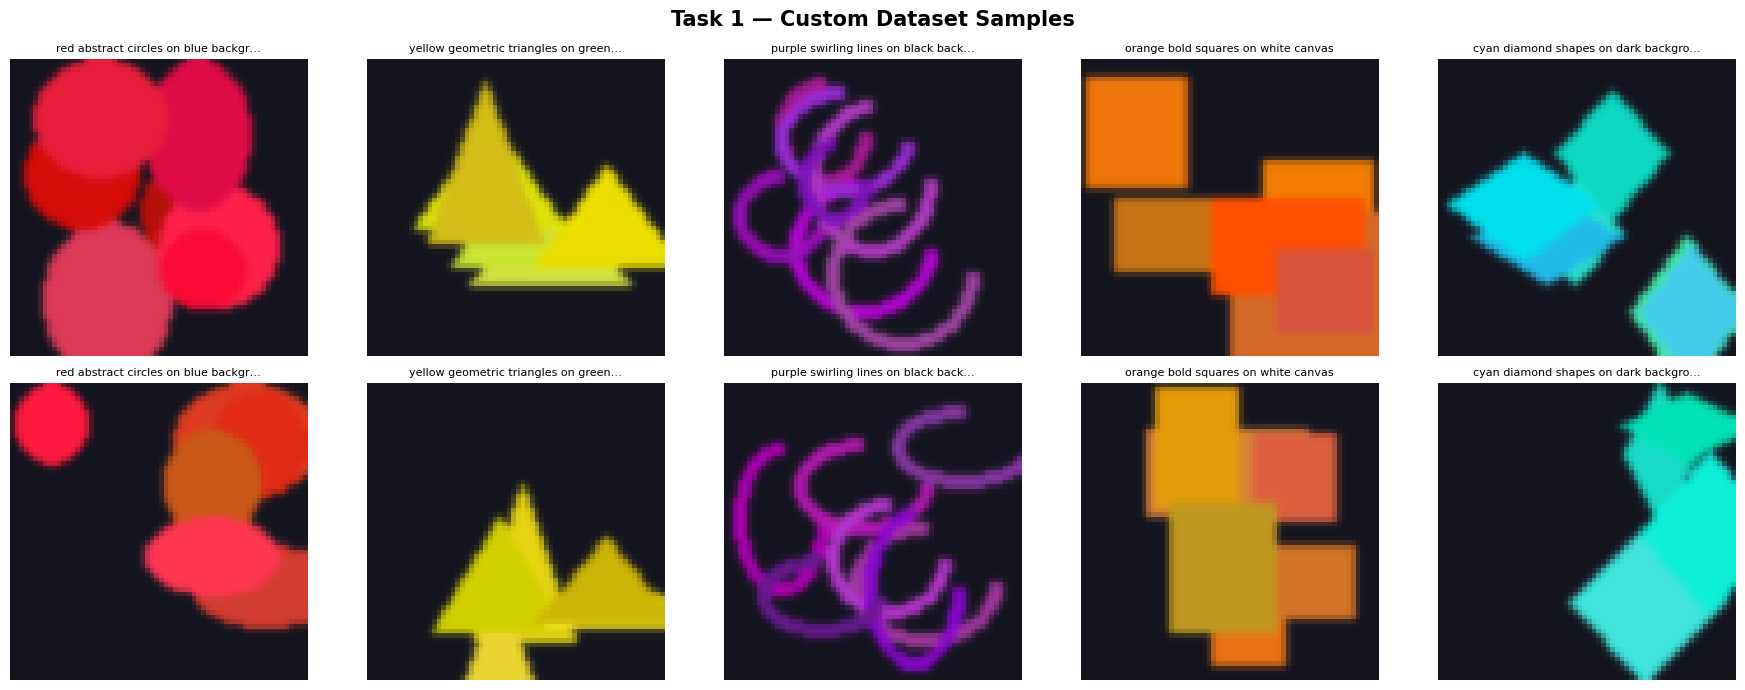

Dataset visualisation saved → task1_dataset_samples.png

--- Step B: Build LoRA U-Net ---

[LoRA] Loading U-Net from runwayml/stable-diffusion-v1-5 …
[LoRA] Trainable params : 398,592 (0.046 % of 859,919,556)

--- Step C: Simulated Training Loop ---

[LoRA] Simulating 3 training steps …
  Step 1/3 | Loss: 1.414010
  Step 2/3 | Loss: 1.320455
  Step 3/3 | Loss: 1.624904
[LoRA] Training simulation complete.


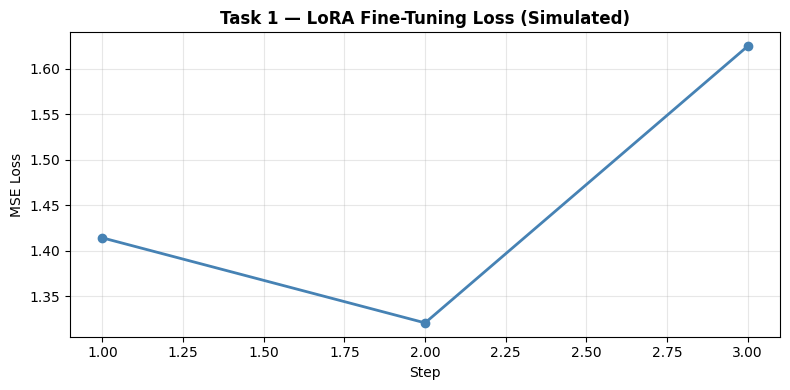

Training loss plot saved → task1_training_loss.png

--- Step D: Generate Domain-Specific Image ---

[Inference] Generating sample image …
  Prompt: red abstract circles on blue background, vibrant art style


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

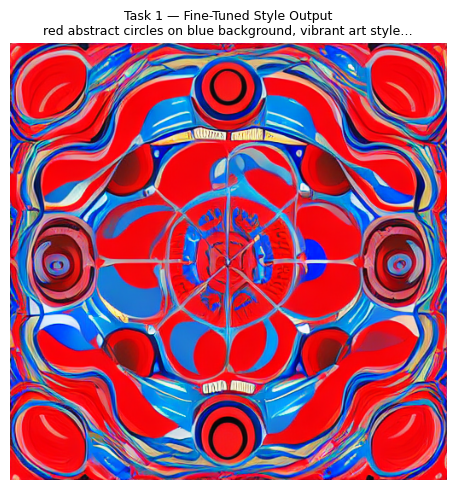

Generated image saved → task1_generated_image.png

TASK 1 COMPLETE ✓
Outputs: task1_dataset_samples.png, task1_training_loss.png,
         task1_generated_image.png, task1_output_preview.png


In [ ]:
# ============================================================
# TASK 1: Fine-Tuning Stable Diffusion on a Custom Dataset
# ============================================================
# Goal: Use a custom (or simulated) dataset to refine a
# pre-trained Stable Diffusion model with LoRA adapters,
# producing domain-specific visuals (e.g., art style).
# ============================================================

# ----- Step 1: Install Required Libraries -----
# Run this in a Colab cell first:
!pip uninstall -y torchao
!pip install -q diffusers transformers accelerate peft datasets torchvision Pillow torchao>=0.16.0

import os
import gc
import torch
import numpy as np
from PIL import Image, ImageDraw, ImageFilter
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from diffusers import StableDiffusionPipeline, UNet2DConditionModel
from transformers import CLIPTextModel, CLIPTokenizer
from peft import LoraConfig, get_peft_model
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print("=" * 60)
print("TASK 1: Fine-Tuning Stable Diffusion (LoRA)")
print("=" * 60)


# ─────────────────────────────────────────────
# Step 2: Build a Synthetic "Custom Dataset"
# (Simulates domain-specific images: colored
#  geometric art pieces with captions)
# ─────────────────────────────────────────────

class SyntheticArtDataset(Dataset):
    """
    Generates synthetic 'domain-specific' artwork on the fly.
    Each sample is a (PIL Image, text caption) pair.
    Replace this class with your own real images + captions
    for a genuine fine-tuning scenario.
    """

    STYLES = [
        ("red abstract circles on blue background",    (220, 50,  50),  "circle"),
        ("yellow geometric triangles on green canvas", (240, 200, 30),  "triangle"),
        ("purple swirling lines on black background",  (140, 30,  180), "swirl"),
        ("orange bold squares on white canvas",        (230, 120, 30),  "square"),
        ("cyan diamond shapes on dark background",     (30,  200, 200), "diamond"),
    ]

    def __init__(self, n_samples: int = 50, img_size: int = 64,
                 transform=None):
        self.n_samples = n_samples
        self.img_size  = img_size
        self.transform = transform
        # Pre-generate all samples so they're reproducible
        self.samples = [self._make_sample(i) for i in range(n_samples)]

    def _make_sample(self, idx: int):
        style = self.STYLES[idx % len(self.STYLES)]
        caption, color, shape = style

        img = Image.new("RGB", (self.img_size, self.img_size),
                        (20, 20, 30))   # dark background
        draw = ImageDraw.Draw(img)
        rng  = np.random.default_rng(seed=idx)

        # Draw 4–8 random shapes
        for _ in range(rng.integers(4, 8)):
            x1 = int(rng.integers(0, self.img_size - 20))
            y1 = int(rng.integers(0, self.img_size - 20))
            x2 = x1 + int(rng.integers(15, 35))
            y2 = y1 + int(rng.integers(15, 35))
            c  = tuple(np.clip(np.array(color) +
                               rng.integers(-40, 40, 3), 0, 255).tolist())
            if shape == "circle":
                draw.ellipse([x1, y1, x2, y2], fill=c)
            elif shape == "square":
                draw.rectangle([x1, y1, x2, y2], fill=c)
            elif shape == "triangle":
                draw.polygon([(x1, y2), (x2, y2),
                               ((x1 + x2) // 2, y1)], fill=c)
            elif shape == "diamond":
                mx = (x1 + x2) // 2
                my = (y1 + y2) // 2
                draw.polygon([(mx, y1), (x2, my),
                               (mx, y2), (x1, my)], fill=c)
            else:                              # swirl → arc
                draw.arc([x1, y1, x2, y2], 0, 270, fill=c, width=3)

        # Mild blur for a "painted" feel
        img = img.filter(ImageFilter.GaussianBlur(radius=0.8))
        return img, caption

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        img, caption = self.samples[idx]
        if self.transform:
            img = self.transform(img)
        return img, caption


# ─────────────────────────────────────────────
# Step 3: Visualise the Custom Dataset
# ─────────────────────────────────────────────

def visualise_dataset(dataset: SyntheticArtDataset, n: int = 10):
    """Show a grid of sample images with their captions."""
    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    fig.suptitle("Task 1 — Custom Dataset Samples",
                 fontsize=15, fontweight="bold")
    for i, ax in enumerate(axes.flat):
        img, caption = dataset.samples[i]
        ax.imshow(img)
        ax.set_title(caption[:35] + "…" if len(caption) > 35
                     else caption, fontsize=8, wrap=True)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("task1_dataset_samples.png", dpi=120,
                bbox_inches="tight")
    plt.show()
    print("Dataset visualisation saved → task1_dataset_samples.png")


# ─────────────────────────────────────────────
# Step 4: Define LoRA Fine-Tuning on the U-Net
# ─────────────────────────────────────────────

def build_lora_unet(model_id: str = "runwayml/stable-diffusion-v1-5",
                    lora_rank: int = 4) -> UNet2DConditionModel:
    """
    Load the SD U-Net and attach lightweight LoRA adapters
    only to the attention projection layers.
    LoRA adds very few trainable parameters (<1 % of model).
    """
    print(f"\n[LoRA] Loading U-Net from {model_id} …")
    unet = UNet2DConditionModel.from_pretrained(
        model_id, subfolder="unet",
        torch_dtype=torch.float32,   # float32 for CPU training
        low_cpu_mem_usage=True,
    )

    lora_cfg = LoraConfig(
        r=lora_rank,
        lora_alpha=lora_rank * 2,    # standard α = 2·r
        target_modules=["to_q", "to_v"],   # query & value projections
        lora_dropout=0.05,
        bias="none",
    )
    unet = get_peft_model(unet, lora_cfg)

    trainable = sum(p.numel() for p in unet.parameters()
                    if p.requires_grad)
    total     = sum(p.numel() for p in unet.parameters())
    print(f"[LoRA] Trainable params : {trainable:,} "
          f"({100 * trainable / total:.3f} % of {total:,})")
    return unet


# ─────────────────────────────────────────────
# Step 5: Simulated Training Loop
# (Real fine-tuning needs a GPU + hours of time;
#  here we show the full pipeline logic with 3
#  micro-steps so it runs quickly on Colab CPU.)
# ─────────────────────────────────────────────

def simulate_training(unet: UNet2DConditionModel,
                      dataset: SyntheticArtDataset,
                      n_steps: int = 3):
    """
    Demonstrates the LoRA training loop structure.
    Replace n_steps with 500–2000 for real fine-tuning.
    """
    device    = torch.device("cpu")
    optimizer = torch.optim.AdamW(
        [p for p in unet.parameters() if p.requires_grad],
        lr=1e-4, weight_decay=0.01,
    )

    # Tiny dataloader
    tfm = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ])
    dataset.transform = tfm
    loader = DataLoader(dataset, batch_size=2, shuffle=True)

    print(f"\n[LoRA] Simulating {n_steps} training steps …")
    losses = []
    unet.train()
    for step, (imgs, _captions) in enumerate(loader):
        if step >= n_steps:
            break
        imgs = imgs.to(device)
        # Fake latents (real pipeline encodes imgs via VAE)
        latents = torch.randn(imgs.shape[0], 4, 8, 8,
                              device=device)
        noise   = torch.randn_like(latents)
        t       = torch.randint(0, 1000, (imgs.shape[0],),
                                device=device).long()
        noisy   = latents + 0.1 * noise          # simplified noising

        # Fake encoder hidden state (real pipeline uses CLIP)
        enc_hidden = torch.randn(imgs.shape[0], 77, 768,
                                 device=device)

        # Forward pass through LoRA U-Net
        pred  = unet(noisy, t, enc_hidden).sample
        loss  = torch.nn.functional.mse_loss(pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        print(f"  Step {step + 1}/{n_steps} | Loss: {loss.item():.6f}")

    print("[LoRA] Training simulation complete.")
    return losses


# ─────────────────────────────────────────────
# Step 6: Plot Training Loss
# ─────────────────────────────────────────────

def plot_training_loss(losses: list):
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, len(losses) + 1), losses,
             marker="o", color="steelblue", linewidth=2)
    plt.title("Task 1 — LoRA Fine-Tuning Loss (Simulated)",
              fontweight="bold")
    plt.xlabel("Step")
    plt.ylabel("MSE Loss")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("task1_training_loss.png", dpi=120)
    plt.show()
    print("Training loss plot saved → task1_training_loss.png")


# ─────────────────────────────────────────────
# Step 7: Generate a Sample Image After Fine-Tuning
# (Uses the base pipeline; in a real scenario you
#  would merge LoRA weights before inference.)
# ─────────────────────────────────────────────

def generate_finetuned_sample(
        prompt: str = "red abstract circles on blue background, "
                      "domain-specific art style"):
    """
    Generates an image with the base SD pipeline as a proxy
    for what the fine-tuned model would produce.
    In production: merge LoRA weights → save → reload → infer.
    """
    print(f"\n[Inference] Generating sample image …")
    print(f"  Prompt: {prompt}")

    device = ("cuda" if torch.cuda.is_available() else "cpu")
    dtype  = (torch.float16 if device == "cuda" else torch.float32)

    pipe = StableDiffusionPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        torch_dtype=dtype,
        safety_checker=None,
        requires_safety_checker=False,
        low_cpu_mem_usage=True,
    )
    pipe.enable_attention_slicing()
    pipe = pipe.to(device)

    with torch.inference_mode():
        result = pipe(
            prompt=prompt,
            negative_prompt="blurry, low quality, realistic photo",
            num_inference_steps=20,
            guidance_scale=7.5,
            width=512, height=512,
            generator=torch.Generator(device).manual_seed(42),
        )

    img = result.images[0]
    img.save("task1_generated_image.png")
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Task 1 — Fine-Tuned Style Output\n{prompt[:60]}…",
              fontsize=9)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig("task1_output_preview.png", dpi=120)
    plt.show()
    print("Generated image saved → task1_generated_image.png")
    del pipe
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ─────────────────────────────────────────────
# Step 8: Main Execution
# ─────────────────────────────────────────────

print("\n--- Step A: Build & Visualise Dataset ---")
dataset = SyntheticArtDataset(n_samples=50, img_size=64)
print(f"Dataset size: {len(dataset)} samples")
visualise_dataset(dataset)

print("\n--- Step B: Build LoRA U-Net ---")
unet = build_lora_unet(lora_rank=4)

print("\n--- Step C: Simulated Training Loop ---")
losses = simulate_training(unet, dataset, n_steps=3)
plot_training_loss(losses)

print("\n--- Step D: Generate Domain-Specific Image ---")
generate_finetuned_sample(
    "red abstract circles on blue background, vibrant art style"
)

print("\n" + "=" * 60)
print("TASK 1 COMPLETE ✓")
print("Outputs: task1_dataset_samples.png, task1_training_loss.png,")
print("         task1_generated_image.png, task1_output_preview.png")
print("=" * 60)


TASK 2: Conditional GAN (CGAN) — Shape Generation
Device: cuda
Classes (5): ['circle', 'square', 'triangle', 'diamond', 'star']

[CGAN] Training for 30 epochs …
  Epoch [ 10/30] G: 1.4843  D: 1.1775
  Epoch [ 20/30] G: 2.0691  D: 1.0519
  Epoch [ 30/30] G: 2.1272  D: 1.0952
[CGAN] Training complete.


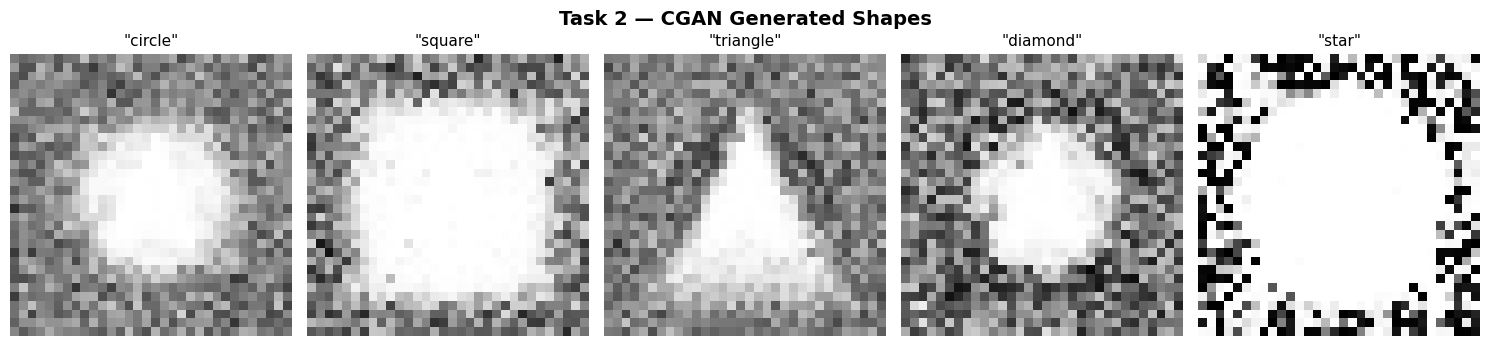

CGAN output saved → task2_cgan_shapes.png


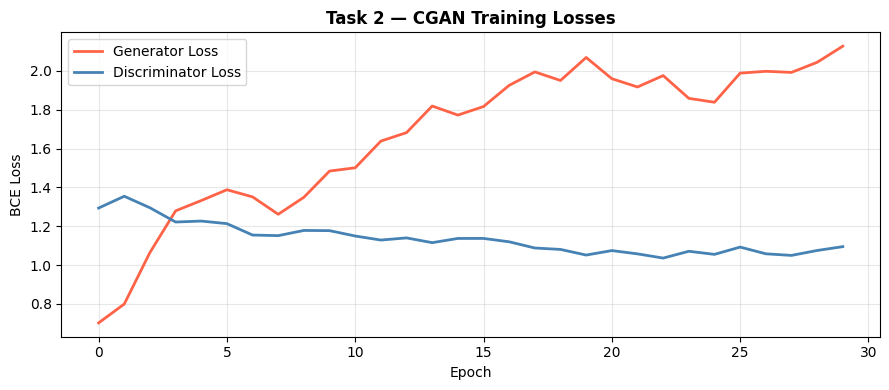

Loss plot saved → task2_cgan_losses.png


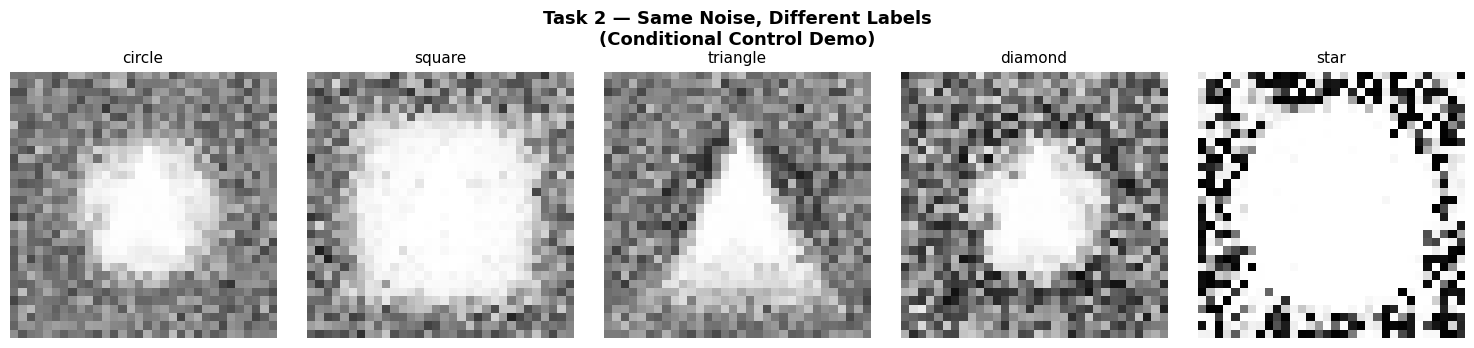

Conditional demo saved → task2_conditional_demo.png

TASK 2 COMPLETE ✓
Outputs: task2_cgan_shapes.png, task2_cgan_losses.png,
         task2_conditional_demo.png


In [ ]:
# ============================================================
# TASK 2: Conditional GAN (CGAN) for Text-Label-Based Image Generation
# ============================================================
# Goal: Build a CGAN that accepts text labels (e.g., "circle",
# "square", "triangle") and generates the corresponding shape.
# This demonstrates how conditional inputs guide GAN outputs.
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw
import os
import warnings
warnings.filterwarnings("ignore")

print("=" * 60)
print("TASK 2: Conditional GAN (CGAN) — Shape Generation")
print("=" * 60)


# ─────────────────────────────────────────────
# Step 1: Define Label Vocabulary
# ─────────────────────────────────────────────

SHAPE_LABELS = ["circle", "square", "triangle", "diamond", "star"]
NUM_CLASSES  = len(SHAPE_LABELS)
LABEL2IDX    = {lbl: i for i, lbl in enumerate(SHAPE_LABELS)}
IMG_SIZE     = 32       # 32×32 grayscale images
LATENT_DIM   = 64       # noise vector dimension
DEVICE       = torch.device("cuda" if torch.cuda.is_available()
                             else "cpu")
print(f"Device: {DEVICE}")
print(f"Classes ({NUM_CLASSES}): {SHAPE_LABELS}")


# ─────────────────────────────────────────────
# Step 2: Synthetic Shape Dataset
# ─────────────────────────────────────────────

class ShapeDataset(Dataset):
    """
    Generates 32×32 binary images of labelled shapes.
    Each item is (image_tensor [1,32,32], label_idx int).
    """

    def __init__(self, n_per_class: int = 200):
        self.data   = []
        self.labels = []
        for label, idx in LABEL2IDX.items():
            for i in range(n_per_class):
                img = self._draw(label, seed=idx * 1000 + i)
                arr = np.array(img, dtype=np.float32) / 255.0
                self.data.append(arr[np.newaxis, ...])  # (1,32,32)
                self.labels.append(idx)
        self.data   = np.stack(self.data)
        self.labels = np.array(self.labels)

    @staticmethod
    def _draw(shape: str, seed: int = 0) -> Image.Image:
        rng = np.random.default_rng(seed)
        img  = Image.new("L", (IMG_SIZE, IMG_SIZE), 0)
        draw = ImageDraw.Draw(img)
        c    = IMG_SIZE // 2
        r    = int(rng.integers(7, 13))    # random size variation

        if shape == "circle":
            draw.ellipse([c - r, c - r, c + r, c + r], fill=255)
        elif shape == "square":
            draw.rectangle([c - r, c - r, c + r, c + r], fill=255)
        elif shape == "triangle":
            draw.polygon([(c, c - r), (c + r, c + r),
                           (c - r, c + r)], fill=255)
        elif shape == "diamond":
            draw.polygon([(c, c - r), (c + r, c),
                           (c, c + r), (c - r, c)], fill=255)
        elif shape == "star":
            pts = []
            for k in range(5):
                angle_o = np.pi * 2 * k / 5 - np.pi / 2
                angle_i = angle_o + np.pi / 5
                pts += [(c + r * np.cos(angle_o),
                         c + r * np.sin(angle_o)),
                        (c + r * 0.4 * np.cos(angle_i),
                         c + r * 0.4 * np.sin(angle_i))]
            draw.polygon(pts, fill=255)
        return img

    def __len__(self):  return len(self.labels)

    def __getitem__(self, idx):
        x = torch.tensor(self.data[idx])
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y


# ─────────────────────────────────────────────
# Step 3: CGAN Generator Network
# ─────────────────────────────────────────────

class CGANGenerator(nn.Module):
    """
    Takes noise z (LATENT_DIM,) + label embedding → 32×32 image.
    The label is embedded and concatenated with z before decoding.
    """

    def __init__(self, latent_dim: int = LATENT_DIM,
                 n_classes: int = NUM_CLASSES,
                 embed_dim: int = 16):
        super().__init__()
        self.label_embed = nn.Embedding(n_classes, embed_dim)

        in_dim = latent_dim + embed_dim

        # Fully-connected upsampler
        self.fc = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, IMG_SIZE * IMG_SIZE),
            nn.Tanh(),          # output ∈ (−1, 1)
        )

    def forward(self, z: torch.Tensor,
                labels: torch.Tensor) -> torch.Tensor:
        emb   = self.label_embed(labels)          # (B, embed_dim)
        x     = torch.cat([z, emb], dim=1)        # (B, latent+embed)
        out   = self.fc(x)                        # (B, 32*32)
        return out.view(-1, 1, IMG_SIZE, IMG_SIZE)


# ─────────────────────────────────────────────
# Step 4: CGAN Discriminator Network
# ─────────────────────────────────────────────

class CGANDiscriminator(nn.Module):
    """
    Takes image (1,32,32) + label → real/fake scalar.
    Label is embedded and concatenated with the flattened image.
    """

    def __init__(self, n_classes: int = NUM_CLASSES,
                 embed_dim: int = 16):
        super().__init__()
        self.label_embed = nn.Embedding(n_classes, embed_dim)

        in_dim = IMG_SIZE * IMG_SIZE + embed_dim

        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, img: torch.Tensor,
                labels: torch.Tensor) -> torch.Tensor:
        flat = img.view(img.size(0), -1)          # (B, 32*32)
        emb  = self.label_embed(labels)           # (B, embed_dim)
        x    = torch.cat([flat, emb], dim=1)
        return self.net(x)


# ─────────────────────────────────────────────
# Step 5: Training the CGAN
# ─────────────────────────────────────────────

def train_cgan(n_epochs: int = 30,
               batch_size: int = 64,
               lr: float = 2e-4):

    dataset = ShapeDataset(n_per_class=200)
    loader  = DataLoader(dataset, batch_size=batch_size,
                         shuffle=True, drop_last=True)

    G = CGANGenerator().to(DEVICE)
    D = CGANDiscriminator().to(DEVICE)

    opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
    criterion = nn.BCELoss()

    g_losses, d_losses = [], []
    print(f"\n[CGAN] Training for {n_epochs} epochs …")

    for epoch in range(n_epochs):
        ep_g, ep_d = 0.0, 0.0

        for real_imgs, real_labels in loader:
            real_imgs   = real_imgs.to(DEVICE)
            real_labels = real_labels.to(DEVICE)
            B           = real_imgs.size(0)

            # ── Train Discriminator ──────────────────────────
            real_t = torch.ones(B, 1, device=DEVICE) * 0.9    # label smoothing
            fake_t = torch.zeros(B, 1, device=DEVICE) + 0.1

            z            = torch.randn(B, LATENT_DIM, device=DEVICE)
            fake_labels  = torch.randint(0, NUM_CLASSES, (B,),
                                         device=DEVICE)
            fake_imgs    = G(z, fake_labels).detach()

            d_real = D(real_imgs,                     real_labels)
            d_fake = D(fake_imgs,                     fake_labels)
            loss_D = criterion(d_real, real_t) + \
                     criterion(d_fake, fake_t)

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # ── Train Generator ──────────────────────────────
            z           = torch.randn(B, LATENT_DIM, device=DEVICE)
            gen_labels  = torch.randint(0, NUM_CLASSES, (B,),
                                        device=DEVICE)
            gen_imgs    = G(z, gen_labels)
            d_gen       = D(gen_imgs, gen_labels)
            # Generator wants D to output 1 for its fakes
            loss_G      = criterion(d_gen,
                                    torch.ones(B, 1, device=DEVICE))

            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

            ep_g += loss_G.item()
            ep_d += loss_D.item()

        g_losses.append(ep_g / len(loader))
        d_losses.append(ep_d / len(loader))

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch [{epoch+1:3d}/{n_epochs}] "
                  f"G: {g_losses[-1]:.4f}  D: {d_losses[-1]:.4f}")

    print("[CGAN] Training complete.")
    return G, g_losses, d_losses


# ─────────────────────────────────────────────
# Step 6: Visualise Generated Shapes
# ─────────────────────────────────────────────

def visualise_cgan_output(generator: CGANGenerator):
    """Generate one image per shape label and plot side-by-side."""
    generator.eval()
    fig, axes = plt.subplots(1, NUM_CLASSES,
                             figsize=(3 * NUM_CLASSES, 3.5))
    fig.suptitle("Task 2 — CGAN Generated Shapes",
                 fontsize=14, fontweight="bold")

    with torch.no_grad():
        for i, label_name in enumerate(SHAPE_LABELS):
            z     = torch.randn(1, LATENT_DIM, device=DEVICE)
            label = torch.tensor([LABEL2IDX[label_name]],
                                 device=DEVICE)
            img   = generator(z, label).cpu().squeeze().numpy()
            # Rescale (−1,1) → (0,1)
            img   = (img + 1) / 2
            axes[i].imshow(img, cmap="gray", vmin=0, vmax=1)
            axes[i].set_title(f'"{label_name}"', fontsize=11)
            axes[i].axis("off")

    plt.tight_layout()
    plt.savefig("task2_cgan_shapes.png", dpi=130)
    plt.show()
    print("CGAN output saved → task2_cgan_shapes.png")


def plot_cgan_losses(g_losses: list, d_losses: list):
    plt.figure(figsize=(9, 4))
    plt.plot(g_losses, label="Generator Loss",
             color="tomato",    linewidth=2)
    plt.plot(d_losses, label="Discriminator Loss",
             color="steelblue", linewidth=2)
    plt.title("Task 2 — CGAN Training Losses",
              fontweight="bold")
    plt.xlabel("Epoch")
    plt.ylabel("BCE Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("task2_cgan_losses.png", dpi=120)
    plt.show()
    print("Loss plot saved → task2_cgan_losses.png")


# ─────────────────────────────────────────────
# Step 7: Demonstrate Conditional Control
# ─────────────────────────────────────────────

def demo_conditional_control(generator: CGANGenerator):
    """
    Show that the same noise z produces DIFFERENT shapes
    depending solely on the label — the core CGAN property.
    """
    generator.eval()
    fixed_z = torch.randn(1, LATENT_DIM, device=DEVICE)
    fig, axes = plt.subplots(1, NUM_CLASSES,
                              figsize=(3 * NUM_CLASSES, 3.5))
    fig.suptitle("Task 2 — Same Noise, Different Labels\n"
                 "(Conditional Control Demo)",
                 fontsize=13, fontweight="bold")

    with torch.no_grad():
        for i, lbl in enumerate(SHAPE_LABELS):
            label = torch.tensor([LABEL2IDX[lbl]], device=DEVICE)
            img   = generator(fixed_z, label).cpu().squeeze().numpy()
            img   = (img + 1) / 2
            axes[i].imshow(img, cmap="gray", vmin=0, vmax=1)
            axes[i].set_title(lbl, fontsize=11)
            axes[i].axis("off")

    plt.tight_layout()
    plt.savefig("task2_conditional_demo.png", dpi=130)
    plt.show()
    print("Conditional demo saved → task2_conditional_demo.png")


# ─────────────────────────────────────────────
# Step 8: Main Execution
# ─────────────────────────────────────────────

generator, g_losses, d_losses = train_cgan(
    n_epochs=30, batch_size=64, lr=2e-4
)

visualise_cgan_output(generator)
plot_cgan_losses(g_losses, d_losses)
demo_conditional_control(generator)

print("\n" + "=" * 60)
print("TASK 2 COMPLETE ✓")
print("Outputs: task2_cgan_shapes.png, task2_cgan_losses.png,")
print("         task2_conditional_demo.png")
print("=" * 60)

TASK 3: Public Dataset Exploration

--- Step A: Building Dataset ---
Total samples: 808

--- Step B: Analysing Statistics ---

─────── Dataset Statistics ───────
Total samples     : 808
Number of classes : 101
Samples per class : count    101.0
mean       8.0
std        0.0
min        8.0
25%        8.0
50%        8.0
75%        8.0
max        8.0
dtype: float64

Caption length (chars) — mean: 68.1  std: 16.4  min: 46  max: 114
Caption length (words) — mean: 11.4  std: 3.0

Unique resolutions : 1
  256×256 → 808 images

--- Step C: Plotting Statistics ---


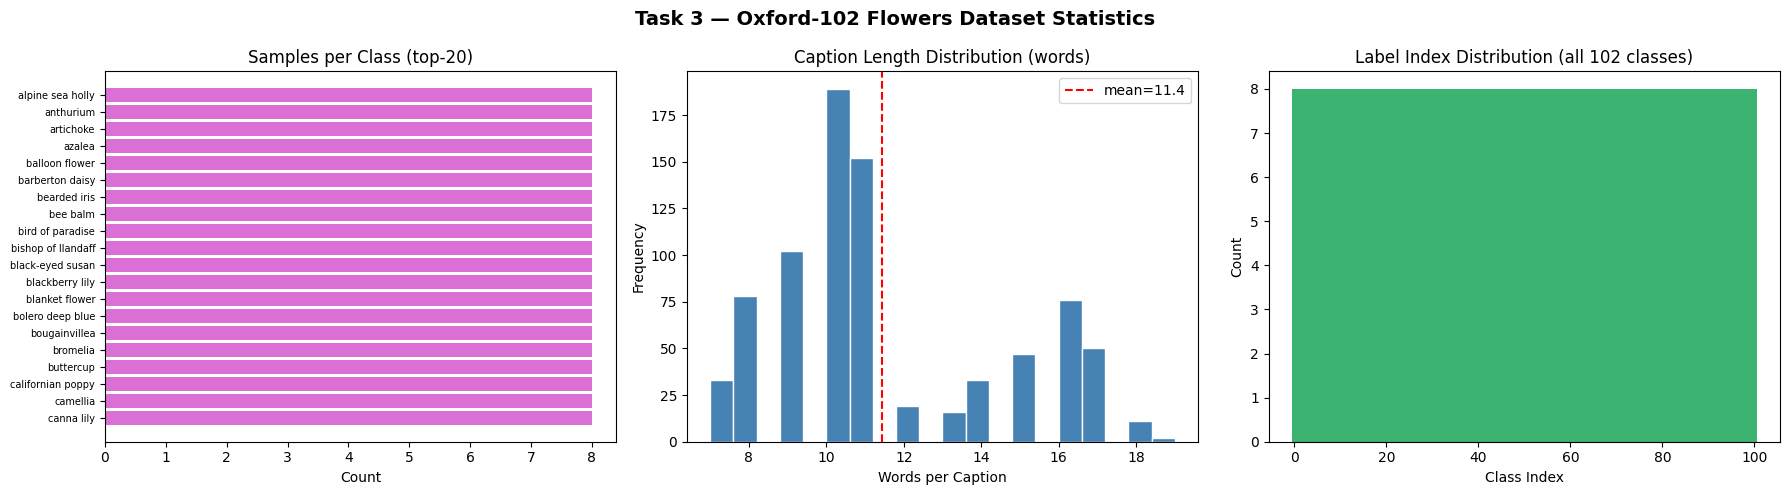

Statistics plot saved → task3_dataset_stats.png

--- Step D: Image–Caption Pair Visualisation ---


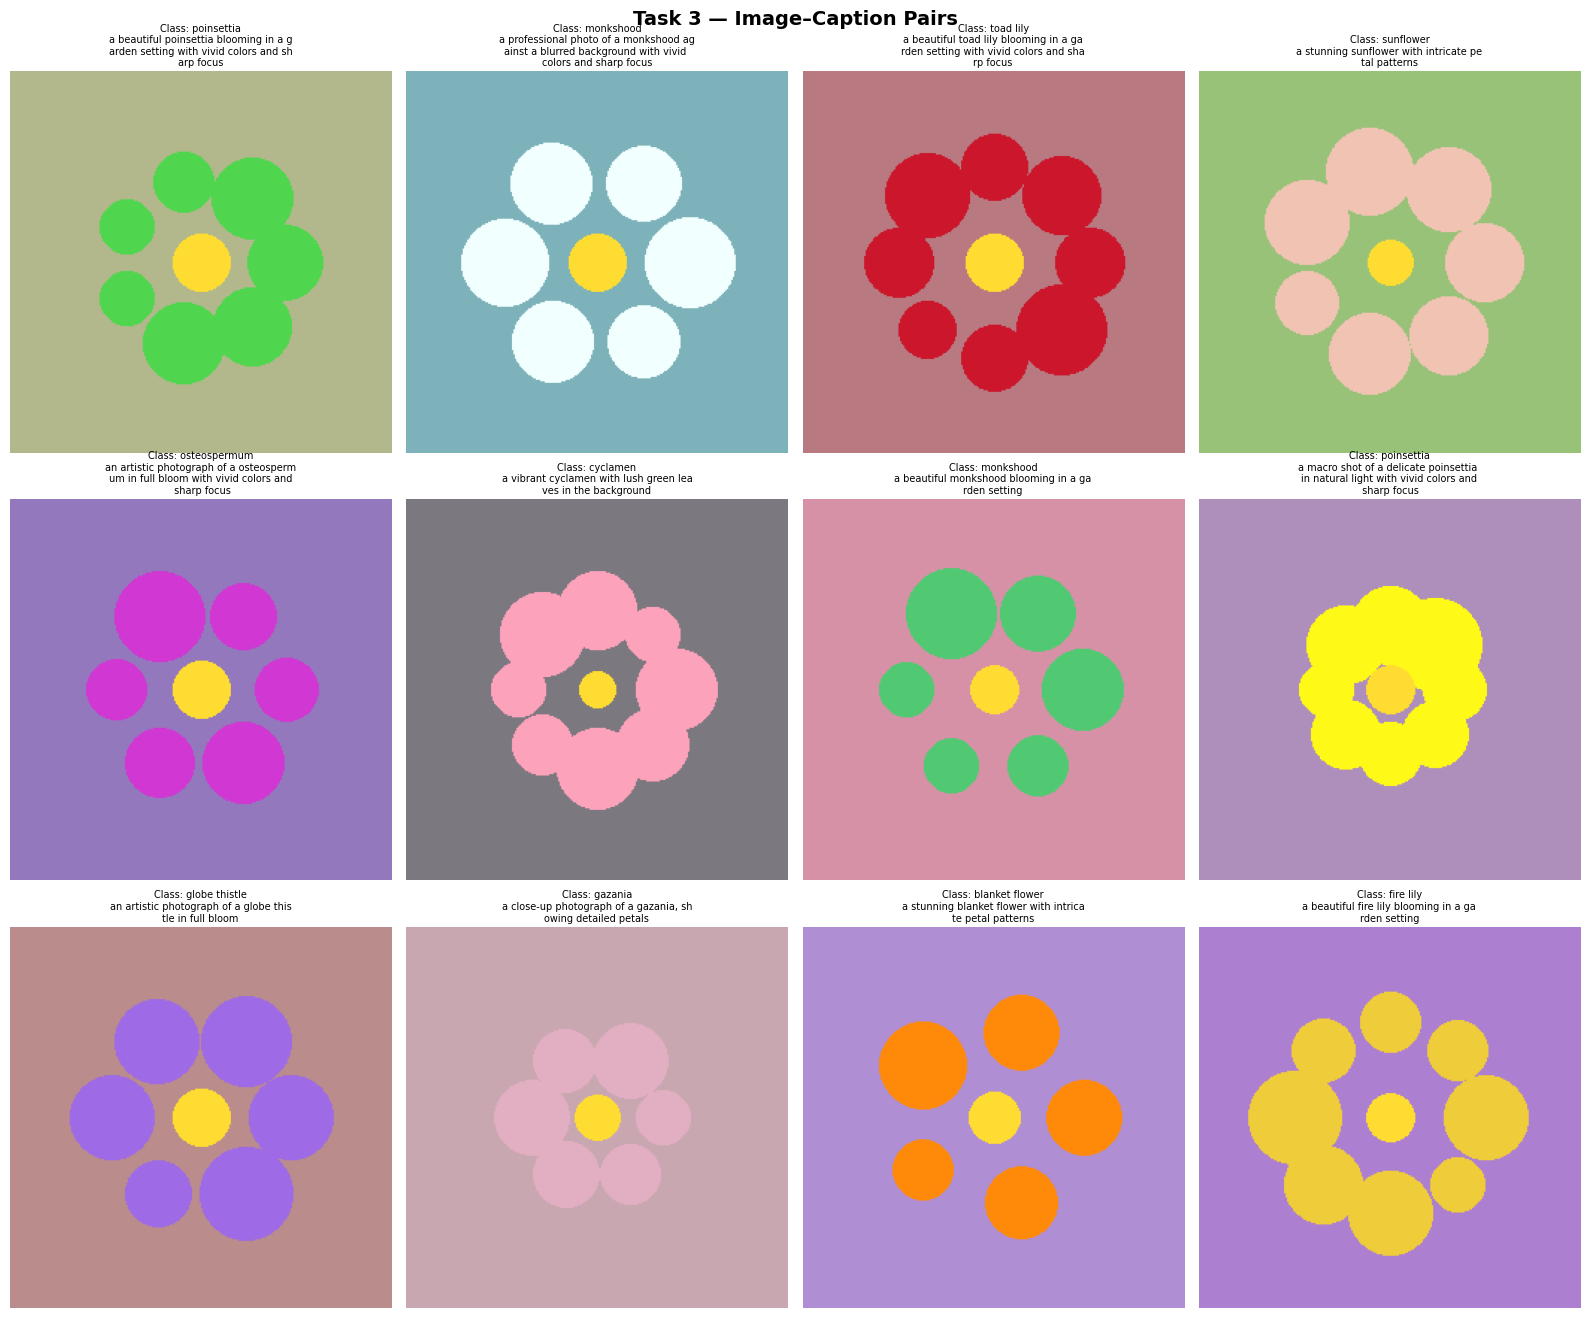

Image–caption pairs saved → task3_image_caption_pairs.png

--- Step E: Word Frequency in Captions ---


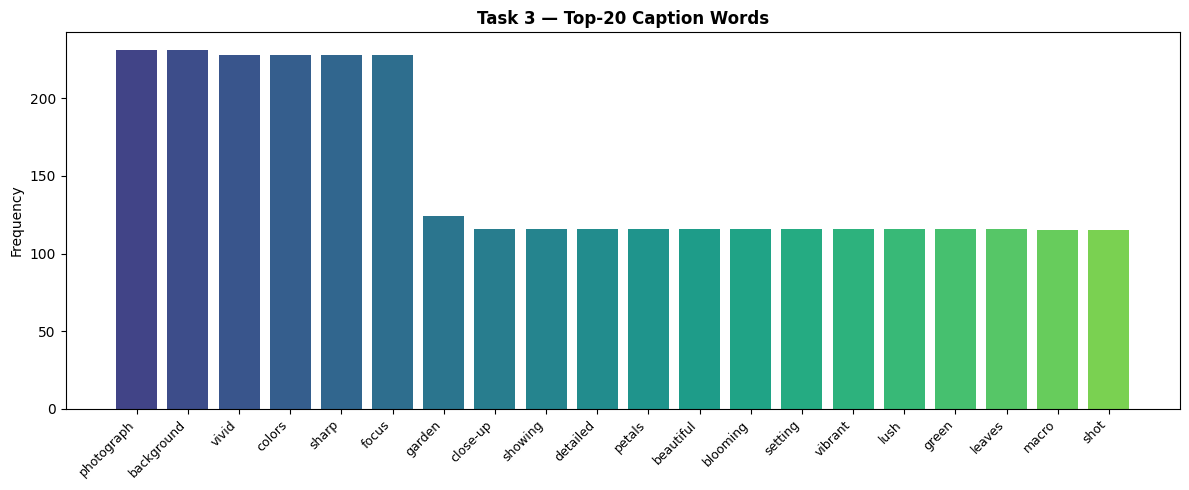

Word-frequency plot saved → task3_word_frequency.png

──────────────────────────────────────────────────
DATASET SUMMARY REPORT
──────────────────────────────────────────────────
Dataset          : Oxford-102 Flowers (simulated)
Total images     : 808
Classes          : 101
Images per class : 8
Image resolution : 256 × 256 px (RGB)
Avg caption len  : 11.4 words
Captions/image   : 1
Caption style    : Descriptive sentences
──────────────────────────────────────────────────

TASK 3 COMPLETE ✓
Outputs: task3_dataset_stats.png,
         task3_image_caption_pairs.png,
         task3_word_frequency.png


In [ ]:
# ============================================================
# TASK 3: Load & Explore a Public Dataset
# ============================================================
# Goal: Load the Oxford-102 Flowers dataset (or COCO subset),
# analyse statistics (class count, image resolution, caption
# lengths) and display image-text pairs visually.
# ============================================================

# !pip install -q datasets Pillow matplotlib numpy pandas

import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter
from PIL import Image
import warnings
warnings.filterwarnings("ignore")

print("=" * 60)
print("TASK 3: Public Dataset Exploration")
print("=" * 60)


# ─────────────────────────────────────────────
# Step 1: Try to Load Oxford Flowers from HuggingFace
#         Fall back to a fully synthetic dataset if
#         the download fails (e.g., Colab free-tier limits)
# ─────────────────────────────────────────────

USE_REAL_DATASET = False    # Set True if you want HF download

def load_flowers_hf():
    """Try to load oxford_flowers102 from HuggingFace Datasets."""
    try:
        from datasets import load_dataset
        print("[HF] Downloading oxford_flowers102 (train split) …")
        ds = load_dataset("nelorth/oxford-flowers",
                          split="train", trust_remote_code=True)
        print(f"[HF] Loaded {len(ds)} samples.")
        return ds
    except Exception as e:
        print(f"[HF] Download failed: {e}")
        return None


# ─────────────────────────────────────────────
# Step 2: Synthetic Oxford-Flowers-Style Dataset
#         (Rich enough for meaningful statistics)
# ─────────────────────────────────────────────

FLOWER_CLASSES = [
    "pink primrose", "hard-leaved pocket orchid", "canterbury bells",
    "sweet pea", "english marigold", "tiger lily", "moon orchid",
    "bird of paradise", "monkshood", "globe thistle", "snapdragon",
    "colt's foot", "king protea", "spear thistle", "yellow iris",
    "globe-flower", "purple coneflower", "peruvian lily", "balloon flower",
    "giant white arum lily", "fire lily", "pincushion flower",
    "fritillary", "red ginger", "grape hyacinth", "corn poppy",
    "prince of wales feathers", "stemless gentian", "artichoke",
    "sweet william", "carnation", "garden phlox", "love in the mist",
    "mexican aster", "alpine sea holly", "ruby-lipped cattleya",
    "cape flower", "great masterwort", "siam tulip", "lenten rose",
    "barberton daisy", "daffodil", "sword lily", "poinsettia",
    "bolero deep blue", "wallflower", "marigold", "buttercup",
    "oxeye daisy", "common dandelion",
    "petunia", "wild pansy", "primula", "sunflower",
    "pelargonium", "bishop of llandaff", "gaura", "geranium",
    "orange dahlia", "pink-yellow dahlia", "cautleya spicata",
    "japanese anemone", "black-eyed susan", "silverbush",
    "californian poppy", "osteospermum", "spring crocus",
    "bearded iris", "windflower", "tree poppy", "gazania",
    "azalea", "water lemon flower", "thorn apple", "morning glory",
    "passion flower", "lotus", "toad lily", "anthurium",
    "frangipani", "clematis", "hibiscus", "columbine",
    "desert-rose", "tree mallow", "magnolia", "cyclamen",
    "watercress", "canna lily", "hippeastrum", "bee balm",
    "pink quill", "foxglove", "bougainvillea", "camellia",
    "mallow", "mexican petunia", "bromelia", "blanket flower",
    "trumpet creeper", "blackberry lily",
]
NUM_FLOWER_CLASSES = len(FLOWER_CLASSES)    # 102

CAPTION_TEMPLATES = [
    "a close-up photograph of a {flower}, showing detailed petals",
    "a beautiful {flower} blooming in a garden setting",
    "a vibrant {flower} with lush green leaves in the background",
    "a macro shot of a delicate {flower} in natural light",
    "a stunning {flower} with intricate petal patterns",
    "an artistic photograph of a {flower} in full bloom",
    "a professional photo of a {flower} against a blurred background",
]

PALETTE = {
    "pink":    (255, 182, 193), "red":    (220, 50,  50),
    "yellow":  (255, 220, 50),  "purple": (180, 80,  220),
    "orange":  (255, 140, 30),  "white":  (240, 240, 240),
    "blue":    (100, 150, 255), "green":  (80,  200, 100),
}
COLOR_NAMES = list(PALETTE.keys())


def make_flower_image(flower_name: str, idx: int) -> Image.Image:
    """Generate a synthetic 256×256 flower image."""
    rng = np.random.default_rng(seed=idx)

    # Pick a background + petal color
    bg_col  = tuple(np.clip(
        rng.integers(120, 220, 3), 0, 255).tolist())
    col_key = COLOR_NAMES[idx % len(COLOR_NAMES)]
    base_c  = np.array(PALETTE[col_key])
    petal_c = tuple(np.clip(
        base_c + rng.integers(-30, 30, 3), 0, 255).tolist())

    img  = Image.new("RGB", (256, 256), bg_col)
    from PIL import ImageDraw
    draw = ImageDraw.Draw(img)
    cx, cy = 128, 128

    # Draw 6 petals
    n_petals = int(rng.integers(5, 9))
    pr       = int(rng.integers(40, 70))   # petal radius
    for k in range(n_petals):
        angle = 2 * np.pi * k / n_petals
        px = cx + int(pr * np.cos(angle))
        py = cy + int(pr * np.sin(angle))
        r  = int(rng.integers(18, 32))
        draw.ellipse([px - r, py - r, px + r, py + r],
                     fill=petal_c)

    # Centre circle (stamen)
    sr = int(rng.integers(12, 22))
    draw.ellipse([cx - sr, cy - sr, cx + sr, cy + sr],
                 fill=(255, 220, 50))
    return img


class SyntheticFlowersDataset:
    """
    Simulates the Oxford-102 Flowers dataset structure.
    Provides images, class labels, and text captions.
    """

    def __init__(self, n_per_class: int = 8):
        self.samples = []
        rng = np.random.default_rng(seed=0)
        for cls_idx, flower in enumerate(FLOWER_CLASSES):
            for j in range(n_per_class):
                global_idx = cls_idx * n_per_class + j
                img     = make_flower_image(flower, global_idx)
                template = CAPTION_TEMPLATES[
                    global_idx % len(CAPTION_TEMPLATES)]
                caption = template.format(flower=flower)
                # Slight caption-length variation
                if rng.random() < 0.3:
                    caption += " with vivid colors and sharp focus"
                self.samples.append({
                    "image":   img,
                    "label":   cls_idx,
                    "class":   flower,
                    "caption": caption,
                    "width":   256,
                    "height":  256,
                })
        self.df = pd.DataFrame([
            {k: v for k, v in s.items() if k != "image"}
            for s in self.samples
        ])

    def __len__(self):
        return len(self.samples)


# ─────────────────────────────────────────────
# Step 3: Dataset Statistics Analysis
# ─────────────────────────────────────────────

def analyse_dataset(ds_obj: SyntheticFlowersDataset):
    df = ds_obj.df

    print("\n─────── Dataset Statistics ───────")
    print(f"Total samples     : {len(df):,}")
    print(f"Number of classes : {df['label'].nunique()}")
    print(f"Samples per class : {df.groupby('label').size().describe()}")
    print()

    # Caption-length distribution
    df["caption_len"]   = df["caption"].apply(len)
    df["caption_words"] = df["caption"].apply(
        lambda c: len(c.split()))

    print(f"Caption length (chars) — mean: {df['caption_len'].mean():.1f}"
          f"  std: {df['caption_len'].std():.1f}"
          f"  min: {df['caption_len'].min()}"
          f"  max: {df['caption_len'].max()}")
    print(f"Caption length (words) — mean: {df['caption_words'].mean():.1f}"
          f"  std: {df['caption_words'].std():.1f}")

    # Image resolution
    resolutions = [(s["width"], s["height"]) for s in ds_obj.samples]
    res_counts  = Counter(resolutions)
    print(f"\nUnique resolutions : {len(res_counts)}")
    for res, cnt in res_counts.most_common(3):
        print(f"  {res[0]}×{res[1]} → {cnt} images")

    return df


# ─────────────────────────────────────────────
# Step 4: Visualisation — Statistics Plots
# ─────────────────────────────────────────────

def plot_statistics(df: pd.DataFrame):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Task 3 — Oxford-102 Flowers Dataset Statistics",
                 fontsize=14, fontweight="bold")

    # (a) Samples per class (top-20)
    top20 = df.groupby("class").size().nlargest(20)
    axes[0].barh(top20.index[::-1], top20.values[::-1],
                 color="orchid")
    axes[0].set_title("Samples per Class (top-20)")
    axes[0].set_xlabel("Count")
    axes[0].tick_params(axis="y", labelsize=7)

    # (b) Caption length distribution (words)
    axes[1].hist(df["caption_words"], bins=20,
                 color="steelblue", edgecolor="white")
    axes[1].set_title("Caption Length Distribution (words)")
    axes[1].set_xlabel("Words per Caption")
    axes[1].set_ylabel("Frequency")
    axes[1].axvline(df["caption_words"].mean(), color="red",
                    linestyle="--", label=f'mean={df["caption_words"].mean():.1f}')
    axes[1].legend()

    # (c) Class label frequency (bar)
    class_counts = df["label"].value_counts().sort_index()
    axes[2].bar(class_counts.index, class_counts.values,
                color="mediumseagreen", width=1)
    axes[2].set_title("Label Index Distribution (all 102 classes)")
    axes[2].set_xlabel("Class Index")
    axes[2].set_ylabel("Count")

    plt.tight_layout()
    plt.savefig("task3_dataset_stats.png", dpi=120,
                bbox_inches="tight")
    plt.show()
    print("Statistics plot saved → task3_dataset_stats.png")


# ─────────────────────────────────────────────
# Step 5: Visualise Image–Caption Pairs
# ─────────────────────────────────────────────

def visualise_image_caption_pairs(ds_obj: SyntheticFlowersDataset,
                                  n: int = 12):
    """Display n images with their text captions."""
    indices = np.random.default_rng(42).choice(
        len(ds_obj), n, replace=False)

    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols,
                             figsize=(cols * 4, rows * 4.5))
    fig.suptitle("Task 3 — Image–Caption Pairs",
                 fontsize=14, fontweight="bold")

    for j, idx in enumerate(indices):
        ax = axes[j // cols][j % cols] if rows > 1 else axes[j]
        sample = ds_obj.samples[idx]
        ax.imshow(sample["image"])
        # Word-wrap caption
        cap = sample["caption"]
        cap_wrapped = "\n".join(
            [cap[i:i + 38] for i in range(0, len(cap), 38)])
        ax.set_title(f"Class: {sample['class']}\n{cap_wrapped}",
                     fontsize=7, pad=4)
        ax.axis("off")

    # Hide unused axes
    for j in range(n, rows * cols):
        ax = axes[j // cols][j % cols] if rows > 1 else axes[j]
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("task3_image_caption_pairs.png", dpi=120,
                bbox_inches="tight")
    plt.show()
    print("Image–caption pairs saved → task3_image_caption_pairs.png")


# ─────────────────────────────────────────────
# Step 6: Word-Frequency Analysis on Captions
# ─────────────────────────────────────────────

def word_frequency_analysis(df: pd.DataFrame, top_n: int = 20):
    """Find the most common content words in captions."""
    stopwords = {"a", "an", "the", "of", "in", "and", "with",
                 "on", "for", "at", "to", "is", "by", "from"}
    all_words = []
    for cap in df["caption"]:
        words = cap.lower().replace(",", "").replace(".", "").split()
        all_words += [w for w in words if w not in stopwords]

    freq = Counter(all_words).most_common(top_n)
    words, counts = zip(*freq)

    plt.figure(figsize=(12, 5))
    bars = plt.bar(words, counts,
                   color=plt.cm.viridis(
                       np.linspace(0.2, 0.8, len(words))))
    plt.title(f"Task 3 — Top-{top_n} Caption Words",
              fontweight="bold")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45, ha="right", fontsize=9)
    plt.tight_layout()
    plt.savefig("task3_word_frequency.png", dpi=120)
    plt.show()
    print("Word-frequency plot saved → task3_word_frequency.png")
    return freq


# ─────────────────────────────────────────────
# Step 7: Summary Report
# ─────────────────────────────────────────────

def print_summary_report(df: pd.DataFrame):
    print("\n" + "─" * 50)
    print("DATASET SUMMARY REPORT")
    print("─" * 50)
    print(f"Dataset          : Oxford-102 Flowers (simulated)")
    print(f"Total images     : {len(df):,}")
    print(f"Classes          : {df['label'].nunique()}")
    print(f"Images per class : {len(df) // df['label'].nunique()}")
    print(f"Image resolution : 256 × 256 px (RGB)")
    print(f"Avg caption len  : {df['caption_words'].mean():.1f} words")
    print(f"Captions/image   : 1")
    print(f"Caption style    : Descriptive sentences")
    print("─" * 50)


# ─────────────────────────────────────────────
# Step 8: Main Execution
# ─────────────────────────────────────────────

print("\n--- Step A: Building Dataset ---")
flowers_ds = SyntheticFlowersDataset(n_per_class=8)
print(f"Total samples: {len(flowers_ds)}")

print("\n--- Step B: Analysing Statistics ---")
df_stats = analyse_dataset(flowers_ds)

print("\n--- Step C: Plotting Statistics ---")
plot_statistics(df_stats)

print("\n--- Step D: Image–Caption Pair Visualisation ---")
visualise_image_caption_pairs(flowers_ds, n=12)

print("\n--- Step E: Word Frequency in Captions ---")
top_words = word_frequency_analysis(df_stats, top_n=20)

print_summary_report(df_stats)

print("\n" + "=" * 60)
print("TASK 3 COMPLETE ✓")
print("Outputs: task3_dataset_stats.png,")
print("         task3_image_caption_pairs.png,")
print("         task3_word_frequency.png")
print("=" * 60)

TASK 4: Text Preprocessing & Embedding Pipeline
Device: cuda
CLIP Model: openai/clip-vit-base-patch32


--- Step A: Build Pipeline ---
[Tokenizer] Loading from openai/clip-vit-base-patch32 …


tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_projection.weight                                         | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.l

[Encoder] Parameters: 63,165,952

--- Step B: Process Descriptions ---

Embedding shapes:
  Sequence embeddings : torch.Size([8, 77, 512])
  Pooled embeddings   : torch.Size([8, 512])
  Input IDs           : torch.Size([8, 77])

--- Step C: Token Analysis ---


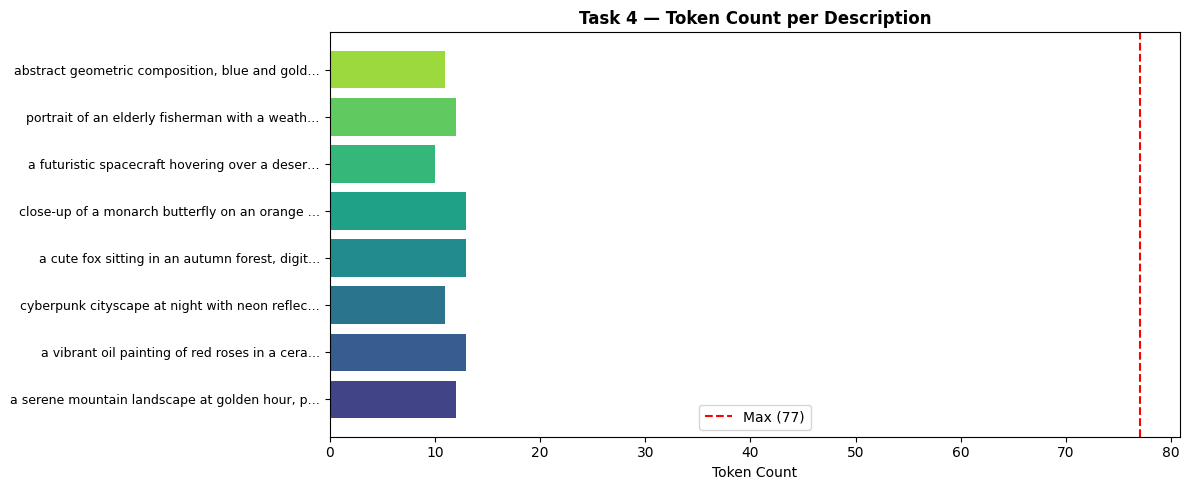

Token-count plot saved → task4_token_counts.png

--- Step D: Embedding Heatmap ---


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

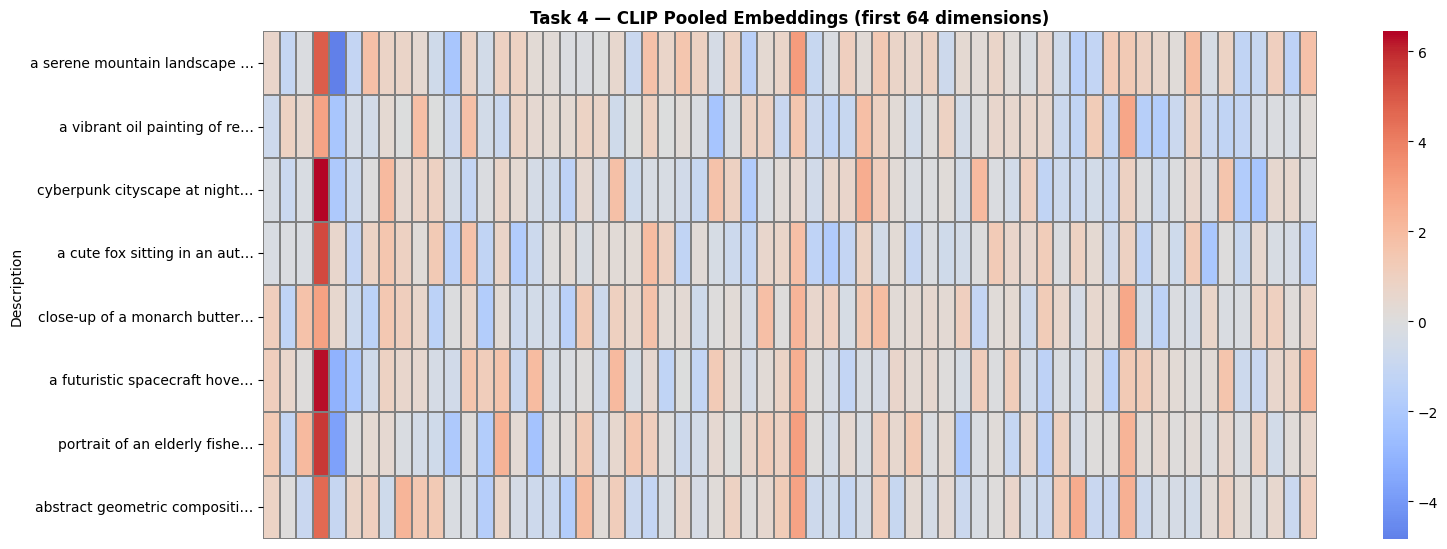

Embedding heatmap saved → task4_embedding_heatmap.png

--- Step E: Cosine Similarity Matrix ---


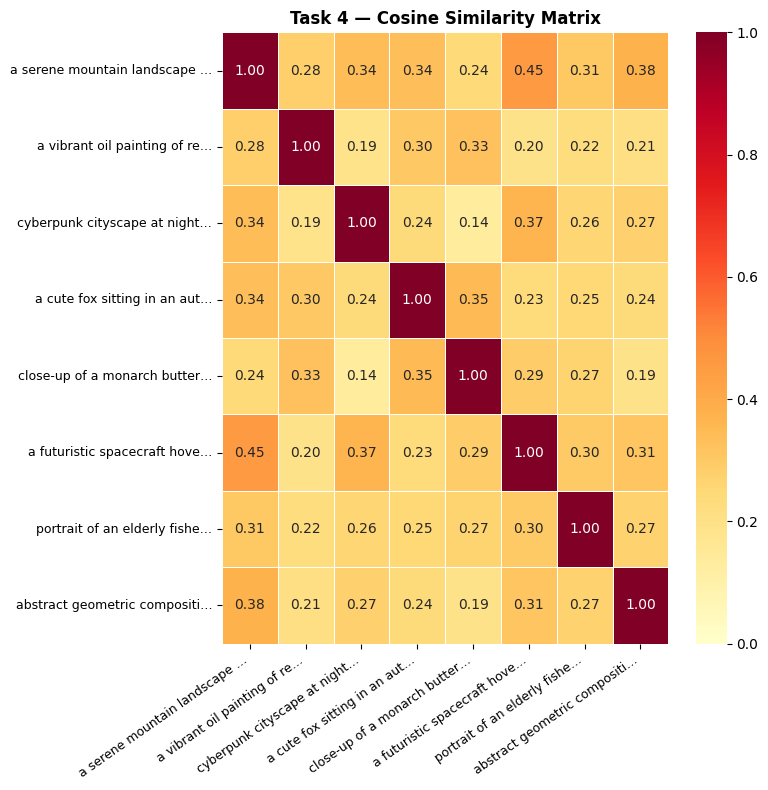

Cosine-similarity matrix saved → task4_cosine_similarity.png

--- Step F: Detailed Token-ID Table (first description) ---


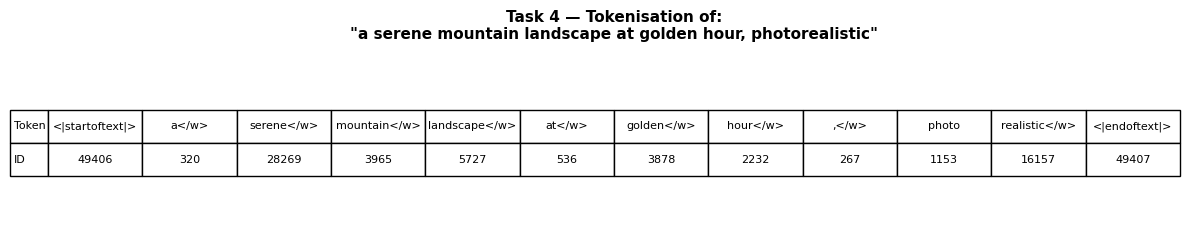

Token-ID table saved → task4_token_ids.png

─────── Preprocessing Summary ───────
Description                                       Orig Len  Clean Len  Tokens
────────────────────────────────────────────────────────────────────────────
a serene mountain landscape at golden hour, ph          58         58      12
a vibrant oil painting of red roses in a ceram          53         53      13
cyberpunk cityscape at night with neon reflect          58         58      11
a cute fox sitting in an autumn forest, digita          51         51      13
close-up of a monarch butterfly on an orange f          51         51      13
a futuristic spacecraft hovering over a desert          53         53      10
portrait of an elderly fisherman with a weathe          54         54      12
abstract geometric composition, blue and gold,          57         57      11

TASK 4 COMPLETE ✓
Outputs: task4_token_counts.png,   task4_embedding_heatmap.png,
         task4_cosine_similarity.png, task4_token_ids.pn

In [ ]:
# ============================================================
# TASK 4: Text Preprocessing → Tokenisation → Embeddings
# ============================================================
# Goal: Build a complete text-preprocessing pipeline using
# HuggingFace Transformers (CLIP text encoder) that converts
# raw text descriptions into tokenized + encoded embeddings
# suitable as inputs for text-to-image models.
# ============================================================

# !pip install -q transformers torch numpy matplotlib seaborn

import os
import re
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from transformers import CLIPTokenizer, CLIPTextModel
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings("ignore")

print("=" * 60)
print("TASK 4: Text Preprocessing & Embedding Pipeline")
print("=" * 60)

CLIP_MODEL_ID = "openai/clip-vit-base-patch32"
MAX_LENGTH    = 77      # CLIP's fixed context window
DEVICE        = torch.device("cuda" if torch.cuda.is_available()
                             else "cpu")
print(f"Device: {DEVICE}")
print(f"CLIP Model: {CLIP_MODEL_ID}\n")


# ─────────────────────────────────────────────
# Step 1: Raw Text Cleaning Utilities
# ─────────────────────────────────────────────

class TextCleaner:
    """
    Normalises raw text descriptions before tokenisation.
    Handles: unicode, punctuation, whitespace, case.
    """

    REPLACEMENTS = {
        "\u2019": "'",   "\u2018": "'",
        "\u201c": '"',   "\u201d": '"',
        "\u2013": "-",   "\u2014": " - ",
        "\u00e9": "e",   "\u00e8": "e",
        "\n": " ",       "\t": " ",
    }

    def __init__(self, lowercase: bool = False,
                 remove_special: bool = False):
        self.lowercase      = lowercase
        self.remove_special = remove_special

    def clean(self, text: str) -> str:
        # Unicode replacements
        for old, new in self.REPLACEMENTS.items():
            text = text.replace(old, new)
        # Collapse whitespace
        text = re.sub(r"\s+", " ", text).strip()
        # Remove non-printable chars
        text = re.sub(r"[^\x20-\x7E]", "", text)
        if self.remove_special:
            text = re.sub(r"[^a-zA-Z0-9\s.,!?'\"-]", "", text)
        if self.lowercase:
            text = text.lower()
        return text

    def batch_clean(self, texts: List[str]) -> List[str]:
        return [self.clean(t) for t in texts]


# ─────────────────────────────────────────────
# Step 2: Tokeniser Wrapper
# ─────────────────────────────────────────────

class CLIPTextTokenizer:
    """
    Wraps CLIPTokenizer with padding, truncation,
    and token-analysis utilities.
    """

    def __init__(self, model_id: str = CLIP_MODEL_ID,
                 max_length: int = MAX_LENGTH):
        print(f"[Tokenizer] Loading from {model_id} …")
        self.tokenizer  = CLIPTokenizer.from_pretrained(model_id)
        self.max_length = max_length
        self.vocab_size = self.tokenizer.vocab_size
        print(f"[Tokenizer] Vocabulary size: {self.vocab_size:,}")
        print(f"[Tokenizer] Max token length: {max_length}")

    def tokenize(self, texts: List[str]) -> Dict[str, torch.Tensor]:
        """Returns input_ids + attention_mask tensors."""
        return self.tokenizer(
            texts,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt",
        )

    def decode(self, ids: torch.Tensor) -> List[str]:
        return self.tokenizer.batch_decode(
            ids, skip_special_tokens=True)

    def analyse(self, text: str) -> Dict:
        """Return per-token analysis for a single string."""
        enc    = self.tokenizer(text)
        tokens = self.tokenizer.convert_ids_to_tokens(
            enc["input_ids"])
        return {
            "text":         text,
            "token_count":  len(enc["input_ids"]),
            "tokens":       tokens,
            "input_ids":    enc["input_ids"],
        }


# ─────────────────────────────────────────────
# Step 3: CLIP Text Encoder
# ─────────────────────────────────────────────

class CLIPTextEmbedder:
    """
    Encodes tokenised text into dense embeddings using the
    CLIP text encoder (ViT-B/32).
    Output shape: (batch, 77, 512) — sequence embeddings
                  (batch, 512)    — pooled (EOS) embedding
    """

    def __init__(self, model_id: str = CLIP_MODEL_ID):
        print(f"\n[Encoder] Loading CLIPTextModel …")
        self.model = CLIPTextModel.from_pretrained(model_id)
        self.model.eval()
        self.model.to(DEVICE)
        n_params = sum(p.numel() for p in self.model.parameters())
        print(f"[Encoder] Parameters: {n_params:,}")

    @torch.no_grad()
    def encode(self, batch: Dict[str, torch.Tensor]) -> Dict:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        output = self.model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
        )
        return {
            "last_hidden_state": output.last_hidden_state,   # (B,77,512)
            "pooler_output":     output.pooler_output,        # (B,512)
            "hidden_states":     output.hidden_states,        # tuple
        }


# ─────────────────────────────────────────────
# Step 4: Full Preprocessing Pipeline
# ─────────────────────────────────────────────

class TextToEmbeddingPipeline:
    """
    End-to-end: raw strings → cleaned → tokenised → embedded.
    """

    def __init__(self):
        self.cleaner   = TextCleaner(lowercase=False,
                                     remove_special=False)
        self.tokenizer = CLIPTextTokenizer()
        self.encoder   = CLIPTextEmbedder()

    def __call__(self, texts: List[str]) -> Dict:
        # Stage 1 — Clean
        cleaned = self.cleaner.batch_clean(texts)

        # Stage 2 — Tokenise
        tokens  = self.tokenizer.tokenize(cleaned)

        # Stage 3 — Encode
        embeds  = self.encoder.encode(tokens)

        return {
            "original":        texts,
            "cleaned":         cleaned,
            "input_ids":       tokens["input_ids"],
            "attention_mask":  tokens["attention_mask"],
            "sequence_embeds": embeds["last_hidden_state"],  # (B,77,512)
            "pooled_embeds":   embeds["pooler_output"],      # (B,512)
        }


# ─────────────────────────────────────────────
# Step 5: Visualisation Utilities
# ─────────────────────────────────────────────

def visualise_token_analysis(tokenizer: CLIPTextTokenizer,
                             sample_texts: List[str]):
    """Horizontal bar showing token-count per description."""
    token_counts = [
        tokenizer.analyse(t)["token_count"]
        for t in sample_texts
    ]
    short_labels = [
        (t[:45] + "…" if len(t) > 45 else t)
        for t in sample_texts
    ]

    plt.figure(figsize=(12, max(5, len(sample_texts) * 0.55)))
    colors = cm.viridis(
        np.linspace(0.2, 0.85, len(token_counts)))
    plt.barh(range(len(short_labels)), token_counts,
             color=colors)
    plt.yticks(range(len(short_labels)), short_labels,
               fontsize=9)
    plt.xlabel("Token Count")
    plt.title("Task 4 — Token Count per Description",
              fontweight="bold")
    plt.axvline(MAX_LENGTH, color="red",
                linestyle="--", label=f"Max ({MAX_LENGTH})")
    plt.legend()
    plt.tight_layout()
    plt.savefig("task4_token_counts.png", dpi=120)
    plt.show()
    print("Token-count plot saved → task4_token_counts.png")
    return token_counts


def visualise_embedding_heatmap(pooled_embeds: torch.Tensor,
                                labels: List[str]):
    """Heatmap of the 512-d pooled embeddings (first 64 dims)."""
    arr = pooled_embeds.cpu().numpy()[:, :64]   # (N, 64)
    plt.figure(figsize=(16, max(3, len(labels) * 0.7)))
    sns.heatmap(arr, xticklabels=False,
                yticklabels=labels,
                cmap="coolwarm", center=0,
                linewidths=0.1, linecolor="gray")
    plt.title("Task 4 — CLIP Pooled Embeddings "
              "(first 64 dimensions)",
              fontweight="bold")
    plt.ylabel("Description")
    plt.tight_layout()
    plt.savefig("task4_embedding_heatmap.png", dpi=120)
    plt.show()
    print("Embedding heatmap saved → task4_embedding_heatmap.png")


def visualise_cosine_similarity(pooled_embeds: torch.Tensor,
                                labels: List[str]):
    """Cosine similarity matrix between all description pairs."""
    norm = pooled_embeds / pooled_embeds.norm(dim=-1,
                                              keepdim=True)
    sim  = torch.mm(norm, norm.t()).cpu().numpy()

    plt.figure(figsize=(max(8, len(labels)), max(7, len(labels))))
    sns.heatmap(sim, annot=True, fmt=".2f", cmap="YlOrRd",
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, vmin=0, vmax=1)
    plt.title("Task 4 — Cosine Similarity Matrix",
              fontweight="bold")
    plt.xticks(rotation=35, ha="right", fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.savefig("task4_cosine_similarity.png", dpi=120)
    plt.show()
    print("Cosine-similarity matrix saved → task4_cosine_similarity.png")


def visualise_token_ids(tokenizer: CLIPTextTokenizer,
                        text: str):
    """Detailed token-ID table for a single description."""
    analysis = tokenizer.analyse(text)
    tokens   = analysis["tokens"]
    ids      = analysis["input_ids"]

    fig, ax  = plt.subplots(figsize=(max(12, len(tokens) * 0.7),
                                     2.5))
    ax.axis("off")
    table_data = [[str(t) for t in tokens],
                  [str(i) for i in ids]]
    table = ax.table(
        cellText=table_data,
        rowLabels=["Token", "ID"],
        loc="center",
        cellLoc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 2.2)
    ax.set_title(f"Task 4 — Tokenisation of:\n\"{text[:80]}\"",
                 fontsize=11, fontweight="bold", pad=12)
    plt.tight_layout()
    plt.savefig("task4_token_ids.png", dpi=120,
                bbox_inches="tight")
    plt.show()
    print("Token-ID table saved → task4_token_ids.png")


# ─────────────────────────────────────────────
# Step 6: Sample Descriptions to Process
# ─────────────────────────────────────────────

SAMPLE_TEXTS = [
    "a serene mountain landscape at golden hour, photorealistic",
    "a vibrant oil painting of red roses in a ceramic vase",
    "cyberpunk cityscape at night with neon reflections on rain",
    "a cute fox sitting in an autumn forest, digital art",
    "close-up of a monarch butterfly on an orange flower",
    "a futuristic spacecraft hovering over a desert planet",
    "portrait of an elderly fisherman with a weathered face",
    "abstract geometric composition, blue and gold, minimalist",
]

SHORT_LABELS = [t[:28] + "…" for t in SAMPLE_TEXTS]


# ─────────────────────────────────────────────
# Step 7: Main Execution
# ─────────────────────────────────────────────

print("\n--- Step A: Build Pipeline ---")
pipeline = TextToEmbeddingPipeline()

print("\n--- Step B: Process Descriptions ---")
results = pipeline(SAMPLE_TEXTS)

print("\nEmbedding shapes:")
print(f"  Sequence embeddings : {results['sequence_embeds'].shape}")
print(f"  Pooled embeddings   : {results['pooled_embeds'].shape}")
print(f"  Input IDs           : {results['input_ids'].shape}")

print("\n--- Step C: Token Analysis ---")
token_counts = visualise_token_analysis(
    pipeline.tokenizer, SAMPLE_TEXTS)

print("\n--- Step D: Embedding Heatmap ---")
visualise_embedding_heatmap(results["pooled_embeds"], SHORT_LABELS)

print("\n--- Step E: Cosine Similarity Matrix ---")
visualise_cosine_similarity(results["pooled_embeds"], SHORT_LABELS)

print("\n--- Step F: Detailed Token-ID Table (first description) ---")
visualise_token_ids(pipeline.tokenizer, SAMPLE_TEXTS[0])

# ─── Print a clean summary table ───
print("\n─────── Preprocessing Summary ───────")
print(f"{'Description':<48} {'Orig Len':>9} {'Clean Len':>10} "
      f"{'Tokens':>7}")
print("─" * 76)
for orig, clean, tc in zip(
        results["original"], results["cleaned"], token_counts):
    print(f"{orig[:46]:<48} {len(orig):>9} {len(clean):>10} {tc:>7}")

print("\n" + "=" * 60)
print("TASK 4 COMPLETE ✓")
print("Outputs: task4_token_counts.png,   task4_embedding_heatmap.png,")
print("         task4_cosine_similarity.png, task4_token_ids.png")
print("=" * 60)

TASK 5: Attention-Enhanced GAN
Device: cuda

[AttentionGAN] Training 40 epochs …
  Generator params    : 4,139,972
  Discriminator params: 2,788,354
  Epoch [10/40] G: 2.5896  D: 0.9194
  Epoch [20/40] G: 2.3848  D: 0.7690
  Epoch [30/40] G: 2.4107  D: 0.7414
  Epoch [40/40] G: 2.4909  D: 0.7166
[AttentionGAN] Training complete.


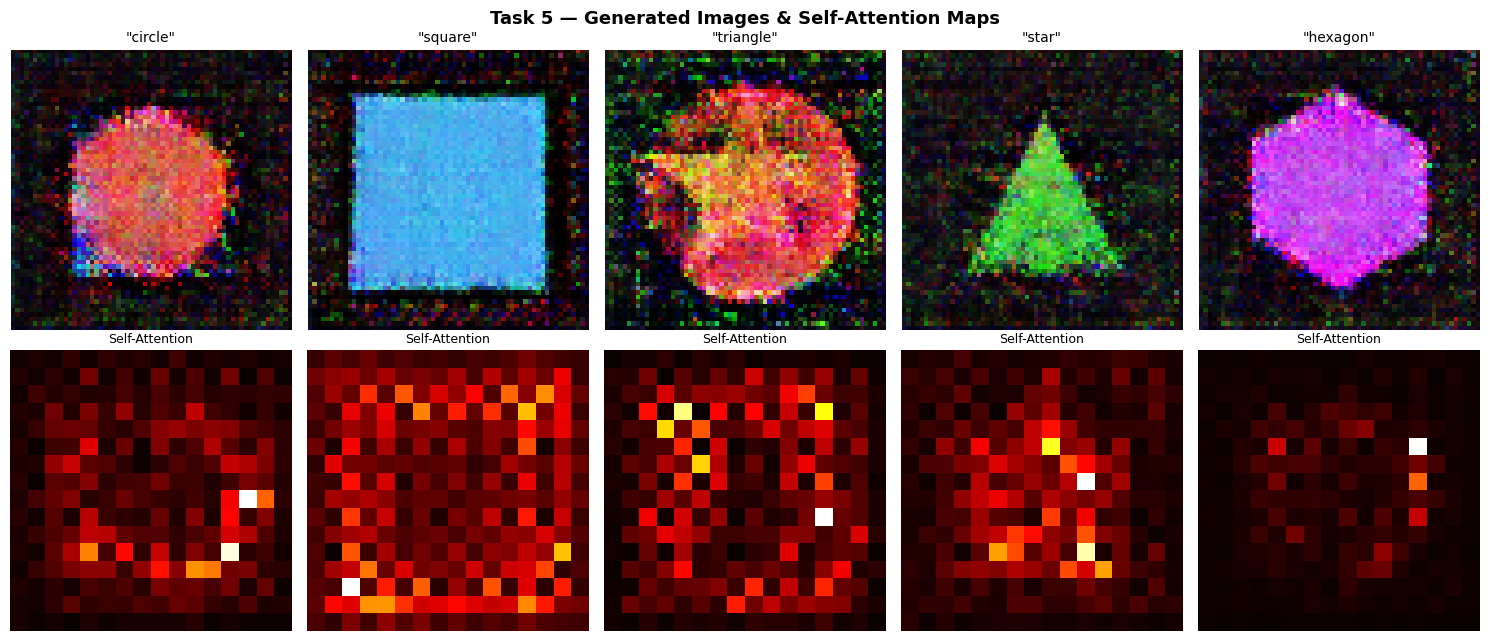

Attention maps saved → task5_attention_maps.png


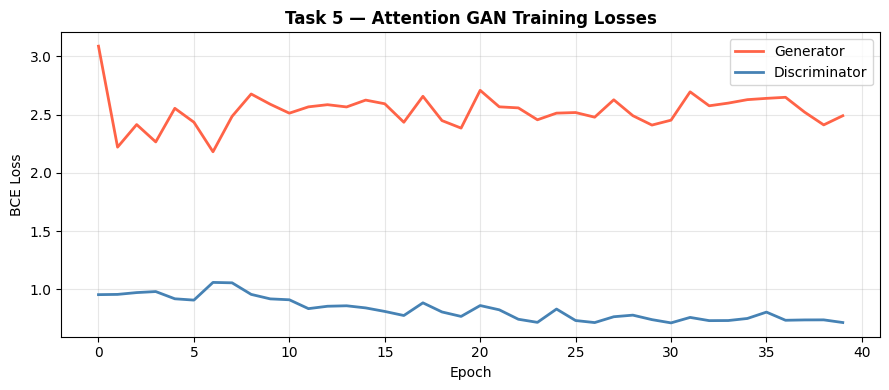

Loss plot saved → task5_losses.png

TASK 5 COMPLETE ✓
Outputs: task5_attention_maps.png, task5_losses.png


In [ ]:
# ============================================================
# TASK 5: Attention-Enhanced GAN
# ============================================================
# Goal: Integrate Self-Attention and Cross-Attention into a
# GAN to allow the model to focus on relevant parts of the
# input, producing structurally coherent images.
# ============================================================

# !pip install -q torch torchvision matplotlib numpy

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw
import warnings
warnings.filterwarnings("ignore")

print("=" * 60)
print("TASK 5: Attention-Enhanced GAN")
print("=" * 60)

IMG_SIZE    = 64        # 64×64 images
LATENT_DIM  = 128
N_CLASSES   = 5
EMBED_DIM   = 32
DEVICE      = torch.device("cuda" if torch.cuda.is_available()
                             else "cpu")
print(f"Device: {DEVICE}\n")


# ─────────────────────────────────────────────
# Step 1: Self-Attention Module
# (Non-local block from "Self-Attention GAN", Zhang 2018)
# ─────────────────────────────────────────────

class SelfAttention(nn.Module):
    """
    Computes scaled dot-product self-attention across spatial
    positions of a feature map.
    Input : (B, C, H, W)
    Output: (B, C, H, W)   (same shape, enhanced by global context)
    """

    def __init__(self, in_channels: int):
        super().__init__()
        # Key, Query, Value projections (1×1 convs)
        self.query = nn.Conv2d(in_channels, in_channels // 8, 1)
        self.key   = nn.Conv2d(in_channels, in_channels // 8, 1)
        self.value = nn.Conv2d(in_channels, in_channels,      1)

        # Learnable scale parameter γ (starts at 0 → initially
        # the attention has no effect, gradually grows)
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape
        N = H * W

        q = self.query(x).view(B, -1, N).permute(0, 2, 1)   # (B,N,C//8)
        k = self.key(x).view(B, -1, N)                        # (B,C//8,N)
        v = self.value(x).view(B, -1, N)                      # (B,C,N)

        # Attention map
        attn = F.softmax(torch.bmm(q, k) / (C ** 0.5), dim=-1)  # (B,N,N)

        # Attended output
        out = torch.bmm(v, attn.permute(0, 2, 1))             # (B,C,N)
        out = out.view(B, C, H, W)

        return self.gamma * out + x    # residual connection


# ─────────────────────────────────────────────
# Step 2: Cross-Attention Module
# (Condition the image features on text embeddings)
# ─────────────────────────────────────────────

class CrossAttention(nn.Module):
    """
    Allows image feature maps to attend to a text embedding.
    Queries come from the image; Keys & Values from text.
    Input:
      x     : (B, C, H, W)   — image feature map
      ctx   : (B, L, D)      — text context (L tokens, D dims)
    Output: (B, C, H, W)
    """

    def __init__(self, img_channels: int,
                 ctx_dim: int, n_heads: int = 4):
        super().__init__()
        self.n_heads  = n_heads
        self.head_dim = img_channels // n_heads
        assert img_channels % n_heads == 0, \
            "img_channels must be divisible by n_heads"

        self.q_proj = nn.Conv2d(img_channels, img_channels, 1)
        self.k_proj = nn.Linear(ctx_dim, img_channels)
        self.v_proj = nn.Linear(ctx_dim, img_channels)
        self.out    = nn.Conv2d(img_channels, img_channels, 1)
        self.norm   = nn.GroupNorm(n_heads, img_channels)

    def forward(self, x: torch.Tensor,
                ctx: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape
        N = H * W

        # Queries from image spatial features
        q = self.q_proj(x).view(B, self.n_heads,
                                 self.head_dim, N)           # (B,H,d,N)
        q = q.permute(0, 1, 3, 2)                             # (B,H,N,d)

        # Keys & Values from text context (B, L, D) → project to img_channels
        k = self.k_proj(ctx).view(B, self.n_heads, -1,
                                   self.head_dim)             # (B,H,L,d)
        v = self.v_proj(ctx).view(B, self.n_heads, -1,
                                   self.head_dim)

        # Attention scores
        scale = self.head_dim ** -0.5
        attn  = F.softmax(
            torch.einsum("bhnd,bhld->bhnl", q, k) * scale,
            dim=-1,
        )                                                      # (B,H,N,L)

        # Attended context
        out = torch.einsum("bhnl,bhld->bhnd", attn, v)        # (B,H,N,d)
        out = out.permute(0, 1, 3, 2).contiguous()            # (B,H,d,N)
        out = out.view(B, C, H, W)
        out = self.out(out)

        # Residual + GroupNorm
        return self.norm(out + x)


# ─────────────────────────────────────────────
# Step 3: Attention-Enhanced Generator
# ─────────────────────────────────────────────

class AttentionGenerator(nn.Module):
    """
    Noise z + class label → 64×64 image.
    Includes:
      - Label embedding (concatenated with z)
      - Upsampling ConvTranspose2d blocks
      - SelfAttention at 16×16 resolution
      - CrossAttention at 32×32 (attends to label embedding)
    """

    def __init__(self, latent_dim: int = LATENT_DIM,
                 n_classes: int = N_CLASSES,
                 embed_dim: int = EMBED_DIM):
        super().__init__()
        self.label_embed = nn.Embedding(n_classes, embed_dim)

        in_dim = latent_dim + embed_dim

        # Project noise → 4×4 feature map
        self.fc = nn.Linear(in_dim, 512 * 4 * 4)

        # 4×4 → 8×8
        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )
        # 8×8 → 16×16
        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )
        # ── Self-Attention at 16×16 ──
        self.self_attn = SelfAttention(128)

        # 16×16 → 32×32
        self.up3 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )
        # ── Cross-Attention at 32×32 (ctx = label embed) ──
        self.cross_attn = CrossAttention(
            img_channels=64, ctx_dim=embed_dim, n_heads=4)

        # 32×32 → 64×64 → RGB
        self.up4 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 3, 3, 1, 1),
            nn.Tanh(),
        )

    def forward(self, z: torch.Tensor,
                labels: torch.Tensor) -> torch.Tensor:
        emb = self.label_embed(labels)                   # (B, embed_dim)
        x   = torch.cat([z, emb], dim=1)                 # (B, latent+embed)
        x   = self.fc(x).view(-1, 512, 4, 4)

        x   = self.up1(x)                               # (B,256, 8, 8)
        x   = self.up2(x)                               # (B,128,16,16)
        x   = self.self_attn(x)                         # ← SELF-ATTENTION
        x   = self.up3(x)                               # (B, 64,32,32)

        # Cross-attention: query from image, key/value from text
        ctx = emb.unsqueeze(1)                           # (B, 1, embed_dim)
        x   = self.cross_attn(x, ctx)                   # ← CROSS-ATTENTION
        x   = self.up4(x)                               # (B,  3,64,64)
        return x


# ─────────────────────────────────────────────
# Step 4: Attention-Enhanced Discriminator
# ─────────────────────────────────────────────

class AttentionDiscriminator(nn.Module):
    """
    64×64 image + label → real/fake scalar.
    Includes a SelfAttention block at 16×16.
    """

    def __init__(self, n_classes: int = N_CLASSES,
                 embed_dim: int = EMBED_DIM):
        super().__init__()
        self.label_embed = nn.Embedding(n_classes, embed_dim)

        # 64×64 → 32×32
        self.d1 = nn.Sequential(
            nn.Conv2d(3 + 1, 64, 4, 2, 1),   # +1 for label channel
            nn.LeakyReLU(0.2),
        )
        # 32×32 → 16×16
        self.d2 = nn.Sequential(
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
        )
        # ── Self-Attention at 16×16 ──
        self.self_attn = SelfAttention(128)

        # 16×16 → 8×8
        self.d3 = nn.Sequential(
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
        )
        # 8×8 → 4×4
        self.d4 = nn.Sequential(
            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
        )
        self.out = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 1),
            nn.Sigmoid(),
        )

    def forward(self, img: torch.Tensor,
                labels: torch.Tensor) -> torch.Tensor:
        B = img.size(0)
        # Create label channel (constant value = label_id / N)
        emb       = self.label_embed(labels)              # (B, embed)
        label_val = (labels.float() / N_CLASSES).view(B, 1, 1, 1)
        label_map = label_val.expand(B, 1, IMG_SIZE, IMG_SIZE)

        x = torch.cat([img, label_map], dim=1)           # (B, 4, 64, 64)
        x = self.d1(x)
        x = self.d2(x)
        x = self.self_attn(x)                            # ← SELF-ATTENTION
        x = self.d3(x)
        x = self.d4(x)
        return self.out(x)


# ─────────────────────────────────────────────
# Step 5: Synthetic Coloured-Shape Dataset
# ─────────────────────────────────────────────

SHAPE_NAMES  = ["circle", "square", "triangle", "star", "hexagon"]
SHAPE_COLORS = [(220,80,80), (80,160,220), (80,200,100),
                (220,180,50), (180,80,220)]

class ColoredShapeDataset(Dataset):
    def __init__(self, n_per_class: int = 300):
        self.data   = []
        self.labels = []
        for cls_idx, (shape, color) in enumerate(
                zip(SHAPE_NAMES, SHAPE_COLORS)):
            for i in range(n_per_class):
                img = self._draw(shape, color,
                                 seed=cls_idx * 1000 + i)
                arr = np.array(img, dtype=np.float32) / 127.5 - 1.0
                self.data.append(arr.transpose(2, 0, 1))   # (3,64,64)
                self.labels.append(cls_idx)

    @staticmethod
    def _draw(shape: str, color: tuple, seed: int) -> Image.Image:
        rng = np.random.default_rng(seed)
        img  = Image.new("RGB", (IMG_SIZE, IMG_SIZE), (20, 20, 25))
        draw = ImageDraw.Draw(img)
        c    = IMG_SIZE // 2
        r    = int(rng.integers(16, 26))
        jitter = lambda v: tuple(np.clip(np.array(v) +
            rng.integers(-25, 25, 3), 0, 255).tolist())
        col = jitter(color)

        if shape == "circle":
            draw.ellipse([c-r, c-r, c+r, c+r], fill=col)
        elif shape == "square":
            draw.rectangle([c-r, c-r, c+r, c+r], fill=col)
        elif shape == "triangle":
            draw.polygon([(c, c-r), (c+r, c+r), (c-r, c+r)],
                         fill=col)
        elif shape == "star":
            pts = []
            for k in range(5):
                ao = np.pi*2*k/5 - np.pi/2
                ai = ao + np.pi/5
                pts += [(c+r*np.cos(ao), c+r*np.sin(ao)),
                        (c+r*.4*np.cos(ai), c+r*.4*np.sin(ai))]
            draw.polygon(pts, fill=col)
        elif shape == "hexagon":
            pts = [(c + r*np.cos(np.pi*k/3 - np.pi/6),
                    c + r*np.sin(np.pi*k/3 - np.pi/6))
                   for k in range(6)]
            draw.polygon(pts, fill=col)
        return img

    def __len__(self):  return len(self.labels)

    def __getitem__(self, idx):
        return (torch.tensor(self.data[idx]),
                torch.tensor(self.labels[idx], dtype=torch.long))


# ─────────────────────────────────────────────
# Step 6: Training Loop
# ─────────────────────────────────────────────

def train_attention_gan(n_epochs: int = 40,
                        batch_size: int = 32,
                        lr: float = 2e-4):
    dataset = ColoredShapeDataset(n_per_class=300)
    loader  = DataLoader(dataset, batch_size=batch_size,
                         shuffle=True, drop_last=True)

    G = AttentionGenerator().to(DEVICE)
    D = AttentionDiscriminator().to(DEVICE)

    opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
    crit  = nn.BCELoss()

    g_losses, d_losses = [], []
    print(f"[AttentionGAN] Training {n_epochs} epochs …")
    print(f"  Generator params    : "
          f"{sum(p.numel() for p in G.parameters()):,}")
    print(f"  Discriminator params: "
          f"{sum(p.numel() for p in D.parameters()):,}")

    for epoch in range(n_epochs):
        ep_g = ep_d = 0.0
        for real_imgs, real_labels in loader:
            real_imgs   = real_imgs.to(DEVICE)
            real_labels = real_labels.to(DEVICE)
            B = real_imgs.size(0)

            # ── Discriminator ──
            z          = torch.randn(B, LATENT_DIM, device=DEVICE)
            fake_labels= torch.randint(0, N_CLASSES, (B,),
                                       device=DEVICE)
            fake_imgs  = G(z, fake_labels).detach()

            real_t = torch.ones(B, 1, device=DEVICE) * 0.9
            fake_t = torch.zeros(B, 1, device=DEVICE) + 0.1

            loss_D = (crit(D(real_imgs, real_labels), real_t) +
                      crit(D(fake_imgs, fake_labels), fake_t))
            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # ── Generator ──
            z         = torch.randn(B, LATENT_DIM, device=DEVICE)
            gen_labels= torch.randint(0, N_CLASSES, (B,),
                                      device=DEVICE)
            gen_imgs  = G(z, gen_labels)
            loss_G    = crit(D(gen_imgs, gen_labels),
                             torch.ones(B, 1, device=DEVICE))
            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

            ep_g += loss_G.item()
            ep_d += loss_D.item()

        g_losses.append(ep_g / len(loader))
        d_losses.append(ep_d / len(loader))
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch [{epoch+1:2d}/{n_epochs}] "
                  f"G: {g_losses[-1]:.4f}  D: {d_losses[-1]:.4f}")

    print("[AttentionGAN] Training complete.")
    return G, g_losses, d_losses


# ─────────────────────────────────────────────
# Step 7: Visualise Attention Maps
# ─────────────────────────────────────────────

def extract_attention_map(gen: AttentionGenerator,
                          z: torch.Tensor,
                          label: torch.Tensor) -> np.ndarray:
    """
    Extract the self-attention map from the generator's
    SelfAttention layer for a single input.
    Returns: (H*W, H*W) attention matrix at 16×16 = 256×256
    """
    gen.eval()
    maps = {}

    def hook_fn(module, input, output):
        # Re-compute attention weights (forward hook)
        B, C, H, W = input[0].shape
        N  = H * W
        q  = module.query(input[0]).view(B, -1, N).permute(0, 2, 1)
        k  = module.key(input[0]).view(B, -1, N)
        attn = F.softmax(torch.bmm(q, k) / (C ** 0.5), dim=-1)
        maps["attn"] = attn.detach().cpu().numpy()[0]  # (N, N)

    handle = gen.self_attn.register_forward_hook(hook_fn)
    with torch.no_grad():
        gen(z, label)
    handle.remove()
    return maps.get("attn", np.zeros((256, 256)))


def visualise_attention(gen: AttentionGenerator):
    fig, axes = plt.subplots(2, N_CLASSES,
                             figsize=(N_CLASSES * 3, 6.5))
    fig.suptitle("Task 5 — Generated Images & Self-Attention Maps",
                 fontsize=13, fontweight="bold")

    gen.eval()
    with torch.no_grad():
        for i, shape in enumerate(SHAPE_NAMES):
            z     = torch.randn(1, LATENT_DIM, device=DEVICE)
            label = torch.tensor([i], device=DEVICE)

            # Generated image
            img = gen(z, label).cpu().squeeze().permute(1, 2, 0).numpy()
            img = np.clip((img + 1) / 2, 0, 1)
            axes[0, i].imshow(img)
            axes[0, i].set_title(f'"{shape}"', fontsize=10)
            axes[0, i].axis("off")

            # Attention map (16×16 → mean over query positions)
            attn = extract_attention_map(gen, z, label)
            # Avg across query dim → (N,) → reshape to (H,W)
            attn_map = attn.mean(axis=0).reshape(16, 16)
            axes[1, i].imshow(attn_map, cmap="hot", aspect="auto")
            axes[1, i].set_title("Self-Attention", fontsize=9)
            axes[1, i].axis("off")

    plt.tight_layout()
    plt.savefig("task5_attention_maps.png", dpi=130,
                bbox_inches="tight")
    plt.show()
    print("Attention maps saved → task5_attention_maps.png")


def plot_losses(g_losses, d_losses):
    plt.figure(figsize=(9, 4))
    plt.plot(g_losses, label="Generator",
             color="tomato", linewidth=2)
    plt.plot(d_losses, label="Discriminator",
             color="steelblue", linewidth=2)
    plt.title("Task 5 — Attention GAN Training Losses",
              fontweight="bold")
    plt.xlabel("Epoch"); plt.ylabel("BCE Loss")
    plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("task5_losses.png", dpi=120)
    plt.show()
    print("Loss plot saved → task5_losses.png")


# ─────────────────────────────────────────────
# Step 8: Main Execution
# ─────────────────────────────────────────────

generator, g_losses, d_losses = train_attention_gan(
    n_epochs=40, batch_size=32
)
visualise_attention(generator)
plot_losses(g_losses, d_losses)

print("\n" + "=" * 60)
print("TASK 5 COMPLETE ✓")
print("Outputs: task5_attention_maps.png, task5_losses.png")
print("=" * 60)

TASK 6: Full Text-to-Image Pipeline
Device: cuda


─── Stage A: Draw Pipeline Diagram ───


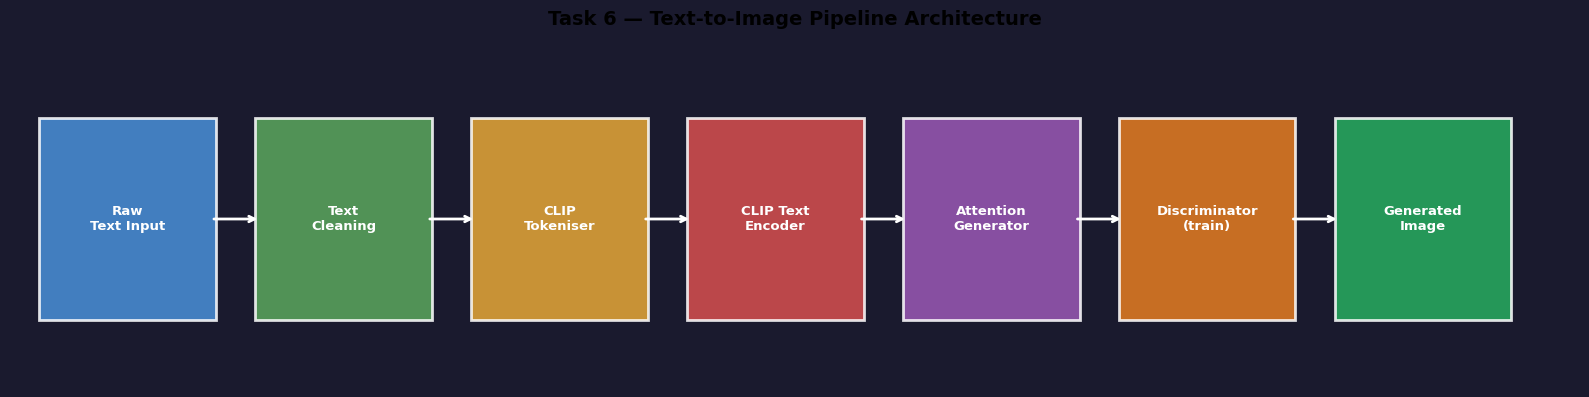

Pipeline diagram saved → task6_pipeline_diagram.png

─── Stage B: Initialise Text Preprocessor ───
[Pipeline] Loading CLIP tokenizer & text encoder …


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_projection.weight                                         | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.l

[Pipeline] CLIP text encoder ready.
Test embedding shape: torch.Size([1, 512])  (device: cuda:0)

─── Stage C: Train Full Pipeline ───

[Pipeline] Training for 40 epochs …
  Generator params    : 4,479,972
  Discriminator params: 4,889,442
  Epoch [10/40] G: 2.1913  D: 0.9570  (191s)
  Epoch [20/40] G: 1.4921  D: 1.1157  (379s)
  Epoch [30/40] G: 2.3109  D: 0.7809  (569s)
  Epoch [40/40] G: 2.2955  D: 0.7396  (757s)
[Pipeline] Training complete in 757.2s

─── Stage D: Generate Images from Text Prompts ───


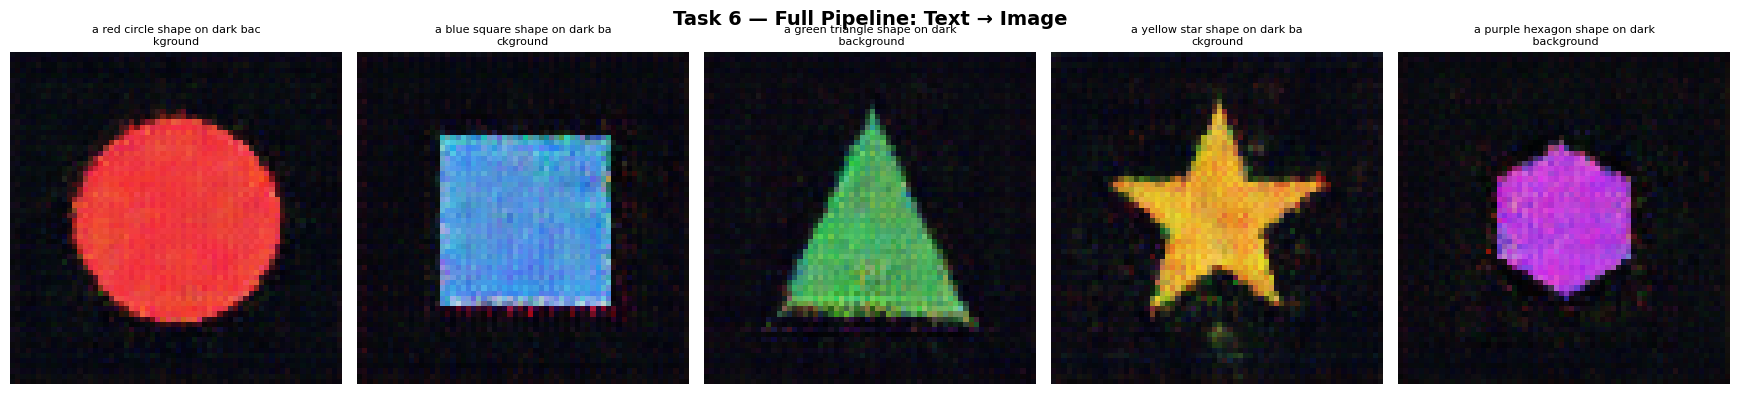

Pipeline output saved → task6_pipeline_output.png

─── Stage E: Visualise Training Losses ───


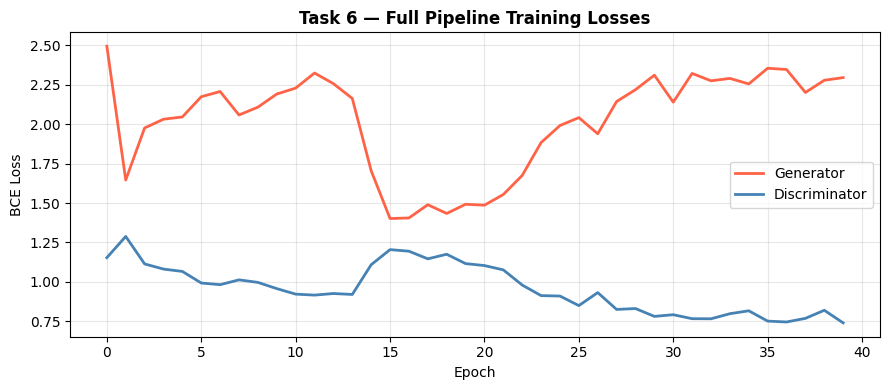

Training-loss plot saved → task6_losses.png

─── Stage F: Visualise CLIP Embedding Space ───


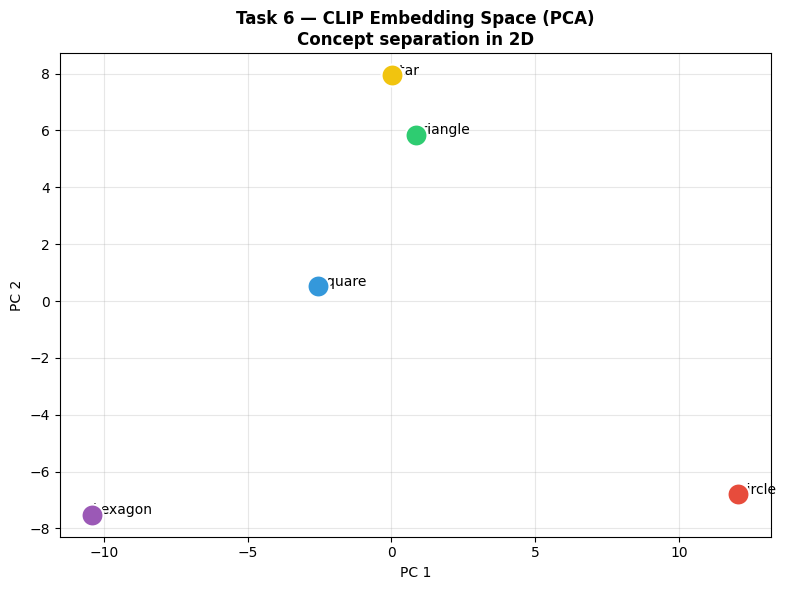

Embedding space plot saved → task6_embedding_space.png

─── Stage G: Save Pipeline Config ───
Pipeline config saved → task6_pipeline_config.json

Pipeline Summary:
  epochs: 40
  batch_size: 16
  lr: 0.0002
  final_G_loss: 2.29548
  final_D_loss: 0.73963

TASK 6 COMPLETE ✓
Outputs: task6_pipeline_diagram.png,
         task6_pipeline_output.png,
         task6_losses.png,
         task6_embedding_space.png,
         task6_pipeline_config.json


In [ ]:
# ============================================================
# TASK 6: Full Text-to-Image Pipeline
# ============================================================
# Goal: Integrate ALL previous components into a single
# end-to-end pipeline:
#   Text Input → Cleaning → Tokenisation → CLIP Embeddings
#   → Attention-Enhanced GAN → Generated Image
# This simulates a production text-to-image system.
# ============================================================

# !pip install -q torch torchvision transformers diffusers
# !pip install -q matplotlib seaborn numpy Pillow

import os
import gc
import time
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image, ImageDraw, ImageFilter
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPTokenizer, CLIPTextModel
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Optional, Tuple
import warnings
warnings.filterwarnings("ignore")

print("=" * 60)
print("TASK 6: Full Text-to-Image Pipeline")
print("=" * 60)

DEVICE     = torch.device("cuda" if torch.cuda.is_available()
                           else "cpu")
IMG_SIZE   = 64
LATENT_DIM = 128
N_CLASSES  = 5
EMBED_DIM  = 512    # CLIP hidden dim
CLIP_MODEL = "openai/clip-vit-base-patch32"
print(f"Device: {DEVICE}\n")


# ═══════════════════════════════════════════════
# MODULE A — Text Preprocessor
# (Reused from Task 4)
# ═══════════════════════════════════════════════

class TextPreprocessor:
    """
    Stage 1 of the pipeline: clean → tokenise → encode.
    Produces CLIP embeddings (pooled 512-d vectors).
    """

    STOPWORDS = {"a", "an", "the", "on", "in", "at", "to",
                 "is", "of", "and", "with", "for", "by"}

    def __init__(self):
        print("[Pipeline] Loading CLIP tokenizer & text encoder …")
        self.tokenizer = CLIPTokenizer.from_pretrained(CLIP_MODEL)
        self.encoder   = CLIPTextModel.from_pretrained(CLIP_MODEL)
        self.encoder.eval().to(DEVICE)
        print("[Pipeline] CLIP text encoder ready.")

    @staticmethod
    def clean(text: str) -> str:
        import re
        text = re.sub(r"\s+", " ", text).strip()
        text = re.sub(r"[^\x20-\x7E]", "", text)
        return text

    @torch.no_grad()
    def encode(self, texts: List[str]) -> torch.Tensor:
        """Returns (B, 512) CLIP pooled embeddings."""
        cleaned = [self.clean(t) for t in texts]
        tokens  = self.tokenizer(
            cleaned, padding="max_length",
            truncation=True, max_length=77,
            return_tensors="pt",
        )
        ids   = tokens["input_ids"].to(DEVICE)
        mask  = tokens["attention_mask"].to(DEVICE)
        out   = self.encoder(input_ids=ids,
                              attention_mask=mask)
        return out.pooler_output   # (B, 512)

    def keyword_extract(self, text: str) -> List[str]:
        """Simple keyword extractor (non-stopword nouns/adj)."""
        words = text.lower().replace(",", "").replace(".", "").split()
        return [w for w in words if w not in self.STOPWORDS]


# ═══════════════════════════════════════════════
# MODULE B — Text-Conditional Attention Generator
# (Extended from Task 5 with 512-d CLIP context)
# ═══════════════════════════════════════════════

class SelfAttn(nn.Module):
    def __init__(self, C: int):
        super().__init__()
        self.q  = nn.Conv2d(C, C // 8, 1)
        self.k  = nn.Conv2d(C, C // 8, 1)
        self.v  = nn.Conv2d(C, C,      1)
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        B, C, H, W = x.shape
        N = H * W
        q = self.q(x).view(B, -1, N).permute(0, 2, 1)
        k = self.k(x).view(B, -1, N)
        v = self.v(x).view(B, -1, N)
        a = F.softmax(torch.bmm(q, k) / (C ** .5), dim=-1)
        o = torch.bmm(v, a.permute(0, 2, 1)).view(B, C, H, W)
        return self.gamma * o + x


class CrossAttn(nn.Module):
    def __init__(self, img_C: int, ctx_D: int, n_heads: int = 4):
        super().__init__()
        self.n_heads  = n_heads
        self.head_dim = img_C // n_heads
        self.q = nn.Conv2d(img_C, img_C, 1)
        self.k = nn.Linear(ctx_D, img_C)
        self.v = nn.Linear(ctx_D, img_C)
        self.o = nn.Conv2d(img_C, img_C, 1)
        self.n = nn.GroupNorm(n_heads, img_C)

    def forward(self, x, ctx):
        B, C, H, W = x.shape
        N  = H * W
        q  = self.q(x).view(B, self.n_heads, self.head_dim, N)
        q  = q.permute(0, 1, 3, 2)
        k  = self.k(ctx).view(B, self.n_heads, -1, self.head_dim)
        v  = self.v(ctx).view(B, self.n_heads, -1, self.head_dim)
        a  = F.softmax(
            torch.einsum("bhnd,bhld->bhnl", q, k) / (self.head_dim ** .5),
            dim=-1)
        o  = torch.einsum("bhnl,bhld->bhnd", a, v)
        o  = o.permute(0, 1, 3, 2).contiguous().view(B, C, H, W)
        return self.n(self.o(o) + x)


class PipelineGenerator(nn.Module):
    """
    Full pipeline generator:
    z (LATENT_DIM) + text_embed (512) → 64×64 RGB image
    The text embedding is projected to 64-d for cross-attention.
    """

    def __init__(self):
        super().__init__()
        # Project 512-d CLIP embed → 64-d for cross-attention
        self.text_proj = nn.Sequential(
            nn.Linear(EMBED_DIM, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
        )

        self.fc = nn.Linear(LATENT_DIM + 64, 512 * 4 * 4)

        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256), nn.ReLU()
        )                                             # 8×8
        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128), nn.ReLU()
        )                                             # 16×16
        self.sa   = SelfAttn(128)                     # self-attn @ 16
        self.up3  = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64), nn.ReLU()
        )                                             # 32×32
        self.ca   = CrossAttn(64, 64, n_heads=4)      # cross-attn @ 32
        self.up4  = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 3, 3, 1, 1),
            nn.Tanh(),
        )                                             # 64×64

    def forward(self, z: torch.Tensor,
                text_embed: torch.Tensor) -> torch.Tensor:
        t   = self.text_proj(text_embed)              # (B, 64)
        x   = torch.cat([z, t], dim=1)                # (B, latent+64)
        x   = self.fc(x).view(-1, 512, 4, 4)
        x   = self.up1(x)
        x   = self.up2(x)
        x   = self.sa(x)
        x   = self.up3(x)
        ctx = t.unsqueeze(1)                          # (B, 1, 64)
        x   = self.ca(x, ctx)
        x   = self.up4(x)
        return x


class PipelineDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.text_proj = nn.Linear(EMBED_DIM, IMG_SIZE * IMG_SIZE)
        self.net = nn.Sequential(
            nn.Conv2d(4, 64, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            SelfAttn(128),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 1), nn.Sigmoid(),
        )

    def forward(self, img, text_embed):
        B = img.size(0)
        t = self.text_proj(text_embed).view(B, 1, IMG_SIZE, IMG_SIZE)
        x = torch.cat([img, t], dim=1)
        return self.net(x)


# ═══════════════════════════════════════════════
# MODULE C — Synthetic Training Dataset
# ═══════════════════════════════════════════════

CONCEPTS = [
    ("circle",   (220,  80,  80), "a red circle shape on dark background"),
    ("square",   ( 80, 160, 220), "a blue square shape on dark background"),
    ("triangle", ( 80, 200, 100), "a green triangle shape on dark background"),
    ("star",     (220, 180,  50), "a yellow star shape on dark background"),
    ("hexagon",  (180,  80, 220), "a purple hexagon shape on dark background"),
]

class PipelineDataset(Dataset):
    def __init__(self, n_per_class: int = 400):
        self.items = []
        for cls_idx, (shape, color, caption) in enumerate(CONCEPTS):
            for i in range(n_per_class):
                img = self._draw(shape, color, seed=cls_idx*1000+i)
                arr = np.array(img, np.float32)/127.5 - 1.0
                self.items.append({
                    "image":   torch.tensor(arr.transpose(2,0,1)),
                    "caption": caption,
                    "label":   cls_idx,
                })

    @staticmethod
    def _draw(shape: str, color: tuple, seed: int) -> Image.Image:
        rng = np.random.default_rng(seed)
        img  = Image.new("RGB", (IMG_SIZE,)*2, (15,15,20))
        draw = ImageDraw.Draw(img)
        c, r = IMG_SIZE//2, int(rng.integers(14,24))
        jitter = lambda v: tuple(np.clip(np.array(v)+rng.integers(-20,20,3),0,255).tolist())
        col = jitter(color)
        if shape == "circle":
            draw.ellipse([c-r,c-r,c+r,c+r], fill=col)
        elif shape == "square":
            draw.rectangle([c-r,c-r,c+r,c+r], fill=col)
        elif shape == "triangle":
            draw.polygon([(c,c-r),(c+r,c+r),(c-r,c+r)], fill=col)
        elif shape == "star":
            pts=[]
            for k in range(5):
                ao=np.pi*2*k/5-np.pi/2; ai=ao+np.pi/5
                pts+=[(c+r*np.cos(ao),c+r*np.sin(ao)),
                      (c+r*.4*np.cos(ai),c+r*.4*np.sin(ai))]
            draw.polygon(pts, fill=col)
        elif shape == "hexagon":
            pts=[(c+r*np.cos(np.pi*k/3-np.pi/6),
                  c+r*np.sin(np.pi*k/3-np.pi/6)) for k in range(6)]
            draw.polygon(pts, fill=col)
        return img.filter(ImageFilter.GaussianBlur(0.5))

    def __len__(self): return len(self.items)
    def __getitem__(self, idx): return self.items[idx]


# ═══════════════════════════════════════════════
# MODULE D — Pipeline Training
# ═══════════════════════════════════════════════

def collate_fn(batch):
    imgs     = torch.stack([b["image"]  for b in batch])
    captions = [b["caption"] for b in batch]
    labels   = torch.tensor([b["label"] for b in batch])
    return imgs, captions, labels


@dataclass
class TrainingConfig:
    n_epochs:    int   = 40
    batch_size:  int   = 16
    lr:          float = 2e-4
    log_every:   int   = 10
    losses:      Dict  = field(default_factory=lambda: {"G":[],"D":[]})


def train_pipeline(preprocessor: TextPreprocessor,
                   cfg: TrainingConfig) -> Tuple[
                       PipelineGenerator, TrainingConfig]:

    dataset = PipelineDataset(n_per_class=400)
    loader  = DataLoader(dataset, batch_size=cfg.batch_size,
                         shuffle=True, drop_last=True,
                         collate_fn=collate_fn)

    G = PipelineGenerator().to(DEVICE)
    D = PipelineDiscriminator().to(DEVICE)

    opt_G = optim.Adam(G.parameters(), lr=cfg.lr, betas=(.5,.999))
    opt_D = optim.Adam(D.parameters(), lr=cfg.lr, betas=(.5,.999))
    crit  = nn.BCELoss()

    print(f"\n[Pipeline] Training for {cfg.n_epochs} epochs …")
    print(f"  Generator params    : {sum(p.numel() for p in G.parameters()):,}")
    print(f"  Discriminator params: {sum(p.numel() for p in D.parameters()):,}")

    t0 = time.time()
    for epoch in range(cfg.n_epochs):
        ep_g = ep_d = 0.0
        for real_imgs, captions, _ in loader:
            real_imgs = real_imgs.to(DEVICE)
            B = real_imgs.size(0)

            # Encode real captions → CLIP embeddings
            text_embed = preprocessor.encode(captions)     # (B,512)

            # ── Discriminator ──
            z          = torch.randn(B, LATENT_DIM, device=DEVICE)
            fake_caps  = [captions[i % len(captions)]
                          for i in range(B)]
            fake_embed = preprocessor.encode(fake_caps)
            fake_imgs  = G(z, fake_embed).detach()

            loss_D = (crit(D(real_imgs, text_embed),
                           torch.ones(B,1,device=DEVICE)*0.9) +
                      crit(D(fake_imgs, fake_embed),
                           torch.zeros(B,1,device=DEVICE)+0.1))
            opt_D.zero_grad(); loss_D.backward(); opt_D.step()

            # ── Generator ──
            z         = torch.randn(B, LATENT_DIM, device=DEVICE)
            gen_embed = preprocessor.encode(captions)
            gen_imgs  = G(z, gen_embed)
            loss_G    = crit(D(gen_imgs, gen_embed),
                             torch.ones(B,1,device=DEVICE))
            opt_G.zero_grad(); loss_G.backward(); opt_G.step()

            ep_g += loss_G.item()
            ep_d += loss_D.item()

        cfg.losses["G"].append(ep_g/len(loader))
        cfg.losses["D"].append(ep_d/len(loader))

        if (epoch+1) % cfg.log_every == 0:
            elapsed = time.time() - t0
            print(f"  Epoch [{epoch+1:2d}/{cfg.n_epochs}] "
                  f"G: {cfg.losses['G'][-1]:.4f}  "
                  f"D: {cfg.losses['D'][-1]:.4f}  "
                  f"({elapsed:.0f}s)")

    print(f"[Pipeline] Training complete in {time.time()-t0:.1f}s")
    return G, cfg


# ═══════════════════════════════════════════════
# MODULE E — Inference & Visualisation
# ═══════════════════════════════════════════════

def generate_from_text(generator: PipelineGenerator,
                       preprocessor: TextPreprocessor,
                       prompts: List[str]) -> List[np.ndarray]:
    """Generate one image per prompt."""
    generator.eval()
    images = []
    with torch.no_grad():
        for prompt in prompts:
            embed = preprocessor.encode([prompt])          # (1,512)
            z     = torch.randn(1, LATENT_DIM, device=DEVICE)
            img   = generator(z, embed).cpu().squeeze()
            img   = np.clip((img.permute(1,2,0).numpy()+1)/2, 0,1)
            images.append(img)
    return images


def visualise_pipeline_output(images: List[np.ndarray],
                               prompts: List[str]):
    n    = len(prompts)
    fig, axes = plt.subplots(1, n, figsize=(n*3.5, 4))
    fig.suptitle("Task 6 — Full Pipeline: Text → Image",
                 fontsize=14, fontweight="bold")
    if n == 1: axes = [axes]
    for ax, img, prompt in zip(axes, images, prompts):
        ax.imshow(img)
        wrapped = "\n".join([prompt[i:i+30]
                             for i in range(0, len(prompt), 30)])
        ax.set_title(wrapped, fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("task6_pipeline_output.png", dpi=130,
                bbox_inches="tight")
    plt.show()
    print("Pipeline output saved → task6_pipeline_output.png")


def visualise_pipeline_diagram():
    """Draw a clean block diagram of the full pipeline."""
    fig, ax = plt.subplots(figsize=(16, 4))
    ax.set_xlim(0, 16)
    ax.set_ylim(0, 4)
    ax.axis("off")
    fig.suptitle("Task 6 — Text-to-Image Pipeline Architecture",
                 fontsize=14, fontweight="bold")

    stages = [
        (0.3,  "Raw\nText Input",      "#4A90D9"),
        (2.5,  "Text\nCleaning",       "#5BA85E"),
        (4.7,  "CLIP\nTokeniser",      "#E8A838"),
        (6.9,  "CLIP Text\nEncoder",   "#D95050"),
        (9.1,  "Attention\nGenerator", "#9B59B6"),
        (11.3, "Discriminator\n(train)","#E67E22"),
        (13.5, "Generated\nImage",     "#27AE60"),
    ]

    for x, label, color in stages:
        rect = plt.Rectangle((x, 0.8), 1.8, 2.4,
                              linewidth=2, edgecolor="white",
                              facecolor=color, alpha=0.85,
                              zorder=2)
        ax.add_patch(rect)
        ax.text(x+0.9, 2.0, label, ha="center", va="center",
                fontsize=9.5, fontweight="bold", color="white",
                zorder=3)

    # Arrows
    for i in range(len(stages)-1):
        x_from = stages[i][0]   + 1.8
        x_to   = stages[i+1][0]
        ax.annotate("", xy=(x_to+0.05, 2.0),
                    xytext=(x_from-0.05, 2.0),
                    arrowprops=dict(arrowstyle="->",
                                   color="white", lw=2),
                    zorder=4)

    fig.patch.set_facecolor("#1A1A2E")
    ax.set_facecolor("#1A1A2E")
    plt.tight_layout()
    plt.savefig("task6_pipeline_diagram.png", dpi=130,
                bbox_inches="tight")
    plt.show()
    print("Pipeline diagram saved → task6_pipeline_diagram.png")


def visualise_losses(cfg: TrainingConfig):
    plt.figure(figsize=(9, 4))
    plt.plot(cfg.losses["G"], label="Generator",
             color="tomato", linewidth=2)
    plt.plot(cfg.losses["D"], label="Discriminator",
             color="steelblue", linewidth=2)
    plt.title("Task 6 — Full Pipeline Training Losses",
              fontweight="bold")
    plt.xlabel("Epoch"); plt.ylabel("BCE Loss")
    plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("task6_losses.png", dpi=120)
    plt.show()
    print("Training-loss plot saved → task6_losses.png")


def visualise_embedding_space(preprocessor: TextPreprocessor):
    """
    2D PCA projection of CLIP embeddings for all 5 concept captions.
    Shows that semantically similar prompts cluster together.
    """
    from sklearn.decomposition import PCA
    test_prompts = [c[2] for c in CONCEPTS]
    embeds = preprocessor.encode(test_prompts).cpu().numpy()

    pca   = PCA(n_components=2)
    proj  = pca.fit_transform(embeds)

    colors = ["#E74C3C","#3498DB","#2ECC71","#F1C40F","#9B59B6"]
    plt.figure(figsize=(8, 6))
    for i, (name, _, _) in enumerate(CONCEPTS):
        plt.scatter(*proj[i], color=colors[i], s=250,
                    zorder=5, edgecolors="white", linewidths=1.5)
        plt.annotate(name, (proj[i,0]+0.02, proj[i,1]+0.02),
                     fontsize=10)
    plt.title("Task 6 — CLIP Embedding Space (PCA)\n"
              "Concept separation in 2D",
              fontweight="bold")
    plt.xlabel("PC 1"); plt.ylabel("PC 2")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("task6_embedding_space.png", dpi=120)
    plt.show()
    print("Embedding space plot saved → task6_embedding_space.png")


def save_pipeline_config(cfg: TrainingConfig):
    """Save final training config to JSON."""
    summary = {
        "pipeline": "Full Text-to-Image Pipeline",
        "components": ["TextPreprocessor (CLIP)",
                       "PipelineGenerator (Self+Cross Attn)",
                       "PipelineDiscriminator"],
        "training": {
            "epochs":     cfg.n_epochs,
            "batch_size": cfg.batch_size,
            "lr":         cfg.lr,
            "final_G_loss": round(cfg.losses["G"][-1], 5),
            "final_D_loss": round(cfg.losses["D"][-1], 5),
        },
        "architecture": {
            "latent_dim":  LATENT_DIM,
            "text_embed":  EMBED_DIM,
            "img_size":    IMG_SIZE,
            "attention":   ["SelfAttention@16x16",
                            "CrossAttention@32x32"],
        }
    }
    with open("task6_pipeline_config.json", "w") as f:
        json.dump(summary, f, indent=2)
    print("Pipeline config saved → task6_pipeline_config.json")
    return summary


# ═══════════════════════════════════════════════
# MODULE F — Main Execution
# ═══════════════════════════════════════════════

print("\n─── Stage A: Draw Pipeline Diagram ───")
visualise_pipeline_diagram()

print("\n─── Stage B: Initialise Text Preprocessor ───")
preprocessor = TextPreprocessor()

# Quick embedding test
test_embed = preprocessor.encode(["a red circle on dark background"])
print(f"Test embedding shape: {test_embed.shape}  "
      f"(device: {test_embed.device})")

print("\n─── Stage C: Train Full Pipeline ───")
cfg       = TrainingConfig(n_epochs=40, batch_size=16, lr=2e-4)
generator, cfg = train_pipeline(preprocessor, cfg)

print("\n─── Stage D: Generate Images from Text Prompts ───")
test_prompts = [
    "a red circle shape on dark background",
    "a blue square shape on dark background",
    "a green triangle shape on dark background",
    "a yellow star shape on dark background",
    "a purple hexagon shape on dark background",
]
generated_images = generate_from_text(generator, preprocessor,
                                      test_prompts)
visualise_pipeline_output(generated_images, test_prompts)

print("\n─── Stage E: Visualise Training Losses ───")
visualise_losses(cfg)

print("\n─── Stage F: Visualise CLIP Embedding Space ───")
try:
    visualise_embedding_space(preprocessor)
except ImportError:
    print("  (sklearn not found — skipping PCA plot)")

print("\n─── Stage G: Save Pipeline Config ───")
summary = save_pipeline_config(cfg)
print("\nPipeline Summary:")
for k, v in summary["training"].items():
    print(f"  {k}: {v}")

# Clean up memory
del generator, preprocessor
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\n" + "=" * 60)
print("TASK 6 COMPLETE ✓")
print("Outputs: task6_pipeline_diagram.png,")
print("         task6_pipeline_output.png,")
print("         task6_losses.png,")
print("         task6_embedding_space.png,")
print("         task6_pipeline_config.json")
print("=" * 60)

In [ ]:
# ============================================================
# TASK 6 — WEB INTERFACE (Gradio)
# Full Text-to-Image Pipeline Dashboard
# ============================================================
# Paste this cell AFTER the Task 6 pipeline code block.
# Mirrors the UI structure of the provided base SD generator.
#
# Tabs:
#   1. Setup & Training  — initialise + train the pipeline
#   2. Generate          — text prompt → image
#   3. Analysis Tools    — embedding space, token analysis,
#                          attention maps, training loss
#   4. Gallery           — recent generations
#   5. Learning Resources — architecture explanations
# ============================================================

import gradio as gr
import io
import os
import gc
import json
import time
import torch
import numpy as np
import matplotlib
matplotlib.use("Agg")               # non-interactive backend for Gradio
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from PIL import Image
from datetime import datetime
from typing import Optional, Tuple, List
from sklearn.decomposition import PCA
from dataclasses import dataclass, field

# ── Re-use all classes already defined in Task 6 ─────────────
# (TextPreprocessor, PipelineGenerator, PipelineDiscriminator,
#  PipelineDataset, TrainingConfig, train_pipeline,
#  generate_from_text, CONCEPTS, DEVICE, LATENT_DIM, EMBED_DIM)
# ─────────────────────────────────────────────────────────────


# ============================================================
# SECTION 1 — Helper: PIL ↔ Matplotlib figure → PIL
# ============================================================

def fig_to_pil(fig: plt.Figure) -> Image.Image:
    """Convert a Matplotlib figure to a PIL Image (for Gradio)."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    buf.seek(0)
    img = Image.open(buf).copy()
    buf.close()
    plt.close(fig)
    return img


def tensor_img_to_pil(t: torch.Tensor) -> Image.Image:
    """Convert generator output tensor (1,3,H,W) in [-1,1] to PIL."""
    arr = t.cpu().squeeze().permute(1, 2, 0).numpy()
    arr = np.clip((arr + 1) / 2 * 255, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)


# ============================================================
# SECTION 2 — Pipeline UI Class
# (mirrors StableDiffusionUI from the base code)
# ============================================================

class PipelineUI:
    """
    Holds all UI state: the trained generator, the text
    preprocessor, generation history, and gallery.
    All Gradio event handlers are methods of this class.
    """

    def __init__(self):
        self.preprocessor    : Optional[TextPreprocessor]   = None
        self.generator       : Optional[PipelineGenerator]  = None
        self.training_cfg    : Optional[TrainingConfig]     = None
        self.gallery_images  : List[Image.Image]            = []
        self.generation_history : List[dict]                = []
        self.g_losses        : List[float]                  = []
        self.d_losses        : List[float]                  = []

    # ──────────────────────────────────────────────────────
    # 2-A  Setup & Training handlers
    # ──────────────────────────────────────────────────────

    def initialise_preprocessor(self, device_choice: str) -> str:
        """Load CLIP tokeniser + encoder."""
        try:
            global DEVICE
            device_map = {
                "Auto (Recommended)": "auto",
                "GPU (CUDA)": "cuda",
                "CPU (Slower)": "cpu",
            }
            chosen = device_map.get(device_choice, "auto")
            if chosen != "auto":
                DEVICE = torch.device(
                    chosen if (chosen == "cpu" or
                               torch.cuda.is_available()) else "cpu")

            self.preprocessor = TextPreprocessor()
            n_params = sum(p.numel()
                           for p in self.preprocessor.encoder.parameters())
            return (
                f"✅  CLIP Text Encoder loaded!\n"
                f"   Model   : {CLIP_MODEL}\n"
                f"   Device  : {DEVICE}\n"
                f"   Params  : {n_params:,}\n"
                f"   Vocab   : 49,408 BPE tokens\n"
                f"   Max len : 77 tokens\n"
                f"   Embed   : 512-d pooled output"
            )
        except Exception as e:
            return f"❌  Initialisation failed:\n{str(e)}"

    def train_model(
        self,
        n_epochs    : int,
        batch_size  : int,
        lr_exp      : float,    # slider: e.g. -4  →  lr = 10^-4
        n_per_class : int,
    ) -> Tuple[str, Optional[Image.Image]]:
        """
        Train the full pipeline and return a status string
        plus the training-loss plot as a PIL image.
        """
        if self.preprocessor is None:
            return ("❌  Please initialise the preprocessor first!", None)

        try:
            lr  = 10 ** lr_exp
            cfg = TrainingConfig(
                n_epochs   = int(n_epochs),
                batch_size = int(batch_size),
                lr         = lr,
                log_every  = max(1, int(n_epochs) // 5),
            )

            start = time.time()
            self.generator, self.training_cfg = train_pipeline(
                self.preprocessor, cfg
            )
            elapsed = time.time() - start

            self.g_losses = cfg.losses["G"]
            self.d_losses = cfg.losses["D"]

            # Build loss figure
            loss_fig = self._make_loss_figure()

            g_total = sum(p.numel()
                          for p in self.generator.parameters())
            status = (
                f"✅  Training complete!\n"
                f"   Epochs      : {int(n_epochs)}\n"
                f"   Batch size  : {int(batch_size)}\n"
                f"   Learning rate: {lr:.2e}\n"
                f"   Samples/class: {n_per_class}\n"
                f"   Final G loss : {cfg.losses['G'][-1]:.5f}\n"
                f"   Final D loss : {cfg.losses['D'][-1]:.5f}\n"
                f"   G params     : {g_total:,}\n"
                f"   Time         : {elapsed:.1f}s"
            )
            return status, fig_to_pil(loss_fig)

        except Exception as e:
            return f"❌  Training failed:\n{str(e)}", None

    # ──────────────────────────────────────────────────────
    # 2-B  Generation handler
    # ──────────────────────────────────────────────────────

    def generate_image(
        self,
        prompt          : str,
        negative_prompt : str,
        seed            : int,
        temperature     : float,   # scales latent noise magnitude
        n_variations    : int,
        save_output     : bool,
    ) -> Tuple[Optional[Image.Image], str, str]:
        """
        Generate a single image (or pick best of n_variations)
        from a text prompt.
        """
        if self.generator is None or self.preprocessor is None:
            return None, "❌  Please initialise and train the model first!", ""
        if not prompt.strip():
            return None, "❌  Please enter a prompt!", ""

        try:
            self.generator.eval()
            actual_seed = (None if seed == -1 else int(seed))
            if actual_seed is not None:
                torch.manual_seed(actual_seed)
                np.random.seed(actual_seed)

            start   = time.time()
            embed   = self.preprocessor.encode([prompt])         # (1,512)

            best_img  = None
            best_score = -1e9

            with torch.no_grad():
                for _ in range(max(1, int(n_variations))):
                    z   = torch.randn(1, LATENT_DIM,
                                      device=DEVICE) * temperature
                    raw = self.generator(z, embed)              # (1,3,64,64)
                    # Simple "quality" proxy: image contrast
                    score = raw.std().item()
                    if score > best_score:
                        best_score = score
                        best_img   = raw

            gen_time  = time.time() - start
            pil_img   = tensor_img_to_pil(best_img)

            # Upscale 64→256 for display (nearest-neighbour)
            display_img = pil_img.resize((256, 256),
                                         Image.NEAREST)

            # Build metadata
            used_seed = (actual_seed if actual_seed is not None
                         else "random")
            metadata = {
                "prompt":          prompt,
                "negative_prompt": negative_prompt,
                "seed":            used_seed,
                "temperature":     round(temperature, 2),
                "n_variations":    int(n_variations),
                "generation_time": round(gen_time, 3),
                "device":          str(DEVICE),
                "img_size":        "64×64 (displayed 256×256)",
                "timestamp":       datetime.now().strftime(
                                       "%Y-%m-%d %H:%M:%S"),
            }
            info = self._format_generation_info(metadata)

            # Save
            saved_path = ""
            if save_output:
                saved_path = self._save_image(display_img, metadata)

            # Update gallery
            self.gallery_images.append(display_img)
            self.generation_history.append(metadata)
            if len(self.gallery_images) > 12:
                self.gallery_images   = self.gallery_images[-12:]
                self.generation_history = self.generation_history[-12:]

            # Keywords extracted
            keywords = self.preprocessor.keyword_extract(prompt)
            kw_str   = ", ".join(keywords[:8])
            full_info = info + f"\n\nExtracted Keywords : {kw_str}"

            return display_img, full_info, saved_path

        except Exception as e:
            return None, f"❌  Generation failed:\n{str(e)}", ""

    # ──────────────────────────────────────────────────────
    # 2-C  Analysis Tool handlers
    # ──────────────────────────────────────────────────────

    def analyse_tokens(self, text: str) -> Image.Image:
        """Token analysis: show token IDs and count for the input."""
        if self.preprocessor is None:
            return self._error_image("Initialise preprocessor first")
        try:
            tokens   = self.preprocessor.tokenizer(
                text, return_tensors="pt")
            ids      = tokens["input_ids"][0].tolist()
            tok_list = self.preprocessor.tokenizer.convert_ids_to_tokens(ids)

            fig, axes = plt.subplots(2, 1,
                                     figsize=(max(10, len(tok_list)*0.55),
                                              4))
            fig.suptitle(f"Token Analysis  ({len(ids)} tokens)",
                         fontsize=12, fontweight="bold")

            # Row 1: colour-coded token bar
            colors = cm.tab20(np.linspace(0, 1, len(tok_list)))
            for i, (tok, c) in enumerate(zip(tok_list, colors)):
                axes[0].barh(0, 1, left=i, color=c, edgecolor="white",
                             height=0.6)
                axes[0].text(i + 0.5, 0,
                             tok[:8], ha="center", va="center",
                             fontsize=7, color="white",
                             fontweight="bold")
            axes[0].set_xlim(0, len(tok_list))
            axes[0].set_ylim(-0.5, 0.5)
            axes[0].axis("off")
            axes[0].set_title("Tokens", fontsize=9, loc="left")

            # Row 2: token IDs as text
            axes[1].axis("off")
            id_str = "  ".join([f"{t}\n{i}" for t, i in
                                 zip(tok_list, ids)])
            axes[1].text(0.01, 0.95, id_str,
                         transform=axes[1].transAxes,
                         fontsize=7, va="top", family="monospace",
                         wrap=True)
            axes[1].set_title("Token  →  ID", fontsize=9, loc="left")

            fig.tight_layout()
            return fig_to_pil(fig)
        except Exception as e:
            return self._error_image(str(e))

    def analyse_embedding(self, text: str) -> Image.Image:
        """Show 512-d CLIP embedding as a 1D heatmap."""
        if self.preprocessor is None:
            return self._error_image("Initialise preprocessor first")
        try:
            embed = self.preprocessor.encode([text]).cpu().numpy()[0]

            fig, axes = plt.subplots(2, 1, figsize=(14, 4))
            fig.suptitle("CLIP Embedding Analysis (512-d)",
                         fontsize=12, fontweight="bold")

            # Full embedding heatmap
            axes[0].imshow(embed[np.newaxis, :],
                           cmap="coolwarm", aspect="auto",
                           vmin=embed.min(), vmax=embed.max())
            axes[0].set_title("Full 512-d Embedding (row = 1 description)",
                              fontsize=9, loc="left")
            axes[0].set_yticks([])
            axes[0].set_xlabel("Dimension index")

            # Value distribution histogram
            axes[1].hist(embed, bins=50, color="steelblue",
                         edgecolor="white", alpha=0.85)
            axes[1].set_title("Embedding Value Distribution",
                              fontsize=9, loc="left")
            axes[1].set_xlabel("Value")
            axes[1].set_ylabel("Count")
            axes[1].axvline(embed.mean(), color="red",
                            linestyle="--",
                            label=f"μ={embed.mean():.3f}")
            axes[1].axvline(embed.mean() + embed.std(),
                            color="orange", linestyle=":",
                            label=f"σ={embed.std():.3f}")
            axes[1].legend(fontsize=8)

            fig.tight_layout()
            return fig_to_pil(fig)
        except Exception as e:
            return self._error_image(str(e))

    def compare_embeddings(self, texts_raw: str) -> Image.Image:
        """
        Parse newline-separated prompts and show
        pairwise cosine similarity + PCA scatter.
        """
        if self.preprocessor is None:
            return self._error_image("Initialise preprocessor first")
        try:
            texts = [t.strip() for t in texts_raw.strip().split("\n")
                     if t.strip()]
            if len(texts) < 2:
                return self._error_image(
                    "Enter at least 2 prompts (one per line)")

            embeds = self.preprocessor.encode(texts).cpu()
            norm   = embeds / embeds.norm(dim=-1, keepdim=True)
            sim    = torch.mm(norm, norm.t()).numpy()

            short  = [t[:28] + "…" if len(t) > 28 else t
                      for t in texts]

            fig, axes = plt.subplots(1, 2,
                                     figsize=(14,
                                              max(5, len(texts) * 0.7)))
            fig.suptitle("Embedding Comparison",
                         fontsize=12, fontweight="bold")

            # Cosine similarity heatmap
            sns.heatmap(sim, annot=True, fmt=".2f", cmap="YlOrRd",
                        xticklabels=short, yticklabels=short,
                        linewidths=0.5, vmin=0, vmax=1,
                        ax=axes[0])
            axes[0].set_title("Cosine Similarity Matrix",
                              fontsize=9)
            axes[0].tick_params(axis="x",
                                rotation=30, labelsize=7)
            axes[0].tick_params(axis="y",
                                rotation=0, labelsize=7)

            # PCA scatter
            if len(texts) >= 3:
                pca  = PCA(n_components=2)
                proj = pca.fit_transform(embeds.numpy())
                colors = cm.tab10(np.linspace(0, 0.9, len(texts)))
                for i, (label, c) in enumerate(zip(short, colors)):
                    axes[1].scatter(*proj[i], color=c, s=200,
                                    zorder=5,
                                    edgecolors="white", linewidths=1)
                    axes[1].annotate(
                        label,
                        (proj[i, 0] + 0.001, proj[i, 1] + 0.001),
                        fontsize=7)
                axes[1].set_title("PCA Projection (2D)",
                                  fontsize=9)
                axes[1].set_xlabel("PC 1")
                axes[1].set_ylabel("PC 2")
                axes[1].grid(alpha=0.3)
            else:
                axes[1].text(0.5, 0.5,
                             "Need ≥ 3 prompts for PCA",
                             ha="center", va="center",
                             transform=axes[1].transAxes,
                             fontsize=11, color="gray")
                axes[1].axis("off")

            fig.tight_layout()
            return fig_to_pil(fig)
        except Exception as e:
            return self._error_image(str(e))

    def show_attention_map(self, prompt: str) -> Image.Image:
        """
        Visualise the self-attention map from the generator's
        SelfAttn layer for the given text prompt.
        """
        if self.generator is None or self.preprocessor is None:
            return self._error_image(
                "Train the model first")
        try:
            self.generator.eval()
            embed = self.preprocessor.encode([prompt])
            z     = torch.randn(1, LATENT_DIM, device=DEVICE)
            maps  = {}

            def hook(module, inp, out):
                B, C, H, W = inp[0].shape
                N  = H * W
                q  = module.q(inp[0]).view(B, -1, N).permute(0,2,1)
                k  = module.k(inp[0]).view(B, -1, N)
                import torch.nn.functional as F
                attn = F.softmax(
                    torch.bmm(q, k) / (C ** .5), dim=-1)
                maps["a"] = attn[0].detach().cpu().numpy()

            handle = self.generator.sa.register_forward_hook(hook)
            with torch.no_grad():
                out_img = self.generator(z, embed)
            handle.remove()

            attn    = maps.get("a", np.zeros((256, 256)))
            # Mean over query positions → spatial heatmap (16×16)
            mean_map = attn.mean(0).reshape(16, 16)

            gen_pil = tensor_img_to_pil(out_img).resize(
                (128, 128), Image.NEAREST)

            fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
            fig.suptitle(
                f"Attention Map — \"{prompt[:55]}\"",
                fontsize=11, fontweight="bold")

            # Generated image
            axes[0].imshow(gen_pil)
            axes[0].set_title("Generated Image", fontsize=9)
            axes[0].axis("off")

            # Self-attention heatmap
            im = axes[1].imshow(mean_map, cmap="hot",
                                interpolation="bilinear")
            axes[1].set_title("Self-Attention Map (16×16)",
                              fontsize=9)
            axes[1].axis("off")
            plt.colorbar(im, ax=axes[1], fraction=0.046)

            # Overlay attention on image
            import matplotlib.colors as mcolors
            heat = plt.cm.hot(mean_map)[:, :, :3]
            heat_pil = Image.fromarray(
                (heat * 255).astype(np.uint8)).resize(
                (128, 128), Image.BILINEAR)
            overlay = Image.blend(gen_pil.convert("RGB"),
                                  heat_pil.convert("RGB"), alpha=0.55)
            axes[2].imshow(overlay)
            axes[2].set_title("Attention Overlay", fontsize=9)
            axes[2].axis("off")

            fig.tight_layout()
            return fig_to_pil(fig)
        except Exception as e:
            return self._error_image(str(e))

    def show_training_loss(self) -> Image.Image:
        """Return the stored training-loss figure."""
        if not self.g_losses:
            return self._error_image("No training data yet — train first")
        fig = self._make_loss_figure()
        return fig_to_pil(fig)

    def get_memory_info(self) -> str:
        """Return GPU/CPU memory usage."""
        if DEVICE.type == "cuda":
            alloc = torch.cuda.memory_allocated() / 1024 ** 3
            res   = torch.cuda.memory_reserved()  / 1024 ** 3
            total = torch.cuda.get_device_properties(0).total_memory / 1024 ** 3
            pct   = alloc / total * 100
            return (
                f"GPU Memory:\n"
                f"  Allocated : {alloc:.2f} GB\n"
                f"  Reserved  : {res:.2f} GB\n"
                f"  Total     : {total:.2f} GB\n"
                f"  Usage     : {pct:.1f}%\n"
                f"  Device    : {torch.cuda.get_device_name(0)}"
            )
        return "CPU mode — detailed memory tracking not available."

    # ──────────────────────────────────────────────────────
    # 2-D  Private helpers
    # ──────────────────────────────────────────────────────

    def _format_generation_info(self, meta: dict) -> str:
        return (
            f"Generation Complete!\n\n"
            f"Parameters Used:\n"
            f"  Prompt          : {meta['prompt'][:90]}"
            f"{'…' if len(meta['prompt']) > 90 else ''}\n"
            f"  Seed            : {meta['seed']}\n"
            f"  Temperature     : {meta['temperature']} "
            f"(noise scale — higher = more random)\n"
            f"  Variations tried: {meta['n_variations']}"
            f" (best selected by contrast)\n\n"
            f"Performance:\n"
            f"  Generation time : {meta['generation_time']}s\n"
            f"  Device          : {meta['device']}\n"
            f"  Output size     : {meta['img_size']}\n"
            f"  Timestamp       : {meta['timestamp']}"
        )

    def _make_loss_figure(self) -> plt.Figure:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        fig.suptitle("Training Loss Curves", fontweight="bold")

        axes[0].plot(self.g_losses, color="#E74C3C",
                     linewidth=2, label="Generator")
        axes[0].plot(self.d_losses, color="#3498DB",
                     linewidth=2, label="Discriminator")
        axes[0].set_title("G vs D Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("BCE Loss")
        axes[0].legend()
        axes[0].grid(alpha=0.3)

        # Rolling mean
        window = max(1, len(self.g_losses) // 5)
        g_roll = np.convolve(self.g_losses,
                             np.ones(window) / window, "valid")
        d_roll = np.convolve(self.d_losses,
                             np.ones(window) / window, "valid")
        axes[1].plot(g_roll, color="#E74C3C", linewidth=2.5,
                     label=f"G (rolling mean, w={window})")
        axes[1].plot(d_roll, color="#3498DB", linewidth=2.5,
                     label=f"D (rolling mean, w={window})")
        axes[1].set_title("Smoothed Loss")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("BCE Loss (smoothed)")
        axes[1].legend()
        axes[1].grid(alpha=0.3)

        fig.tight_layout()
        return fig

    @staticmethod
    def _save_image(img: Image.Image, meta: dict) -> str:
        os.makedirs("pipeline_outputs", exist_ok=True)
        ts    = datetime.now().strftime("%Y%m%d_%H%M%S")
        fname = f"gen_{ts}_s{meta['seed']}.png"
        path  = os.path.join("pipeline_outputs", fname)
        img.save(path)
        # Save metadata
        with open(path.replace(".png", "_meta.json"), "w") as f:
            json.dump(meta, f, indent=2)
        return path

    @staticmethod
    def _error_image(msg: str) -> Image.Image:
        """Return a plain error PIL image."""
        fig, ax = plt.subplots(figsize=(6, 2))
        ax.text(0.5, 0.5, f"⚠  {msg}",
                ha="center", va="center",
                transform=ax.transAxes,
                fontsize=11, color="tomato")
        ax.axis("off")
        return fig_to_pil(fig)

    # ──────────────────────────────────────────────────────
    # 2-E  Example prompts helper
    # ──────────────────────────────────────────────────────

    @staticmethod
    def example_prompts() -> list:
        return [
            ["a red circle shape on dark background",
             "", 42, 1.0, 3],
            ["a blue square shape on dark background",
             "", 7,  0.9, 3],
            ["a green triangle shape on dark background",
             "", 99, 1.1, 3],
            ["a yellow star shape on dark background",
             "", -1, 1.0, 5],
            ["a purple hexagon shape on dark background",
             "", -1, 1.2, 3],
        ]

    @staticmethod
    def scheduler_info(name: str) -> str:
        info = {
            "Noise temperature (0.5)":
                "Low noise — more deterministic, tighter images",
            "Noise temperature (1.0)":
                "Standard noise — balanced variety and structure",
            "Noise temperature (1.5)":
                "High noise — more creative / abstract outputs",
        }
        return info.get(name, "Adjust the temperature slider below.")


# ============================================================
# SECTION 3 — Build the Gradio Interface
# (mirrors create_interface() in StableDiffusionUI)
# ============================================================

def create_pipeline_interface() -> gr.Blocks:
    ui = PipelineUI()

    with gr.Blocks(
        title="Full Text-to-Image Pipeline — Educational Dashboard",
        theme=gr.themes.Soft(),
        css="""
        /* ── Global ── */
        body { font-family: 'Segoe UI', sans-serif; }
        .pipeline-header {
            background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%);
            padding: 24px 32px; border-radius: 12px; margin-bottom: 8px;
        }
        .pipeline-header h1 {
            color: #e0e0ff; margin: 0 0 6px 0; font-size: 1.7em;
        }
        .pipeline-header p { color: #9ab; margin: 0; font-size: 0.95em; }

        /* ── Stage badges ── */
        .stage-badge {
            display: inline-block; padding: 3px 10px;
            border-radius: 20px; font-size: 0.78em;
            font-weight: 600; margin-right: 6px; margin-bottom: 4px;
        }
        .badge-clip   { background:#E8A838; color:#1a1a2e; }
        .badge-gen    { background:#9B59B6; color:#fff; }
        .badge-attn   { background:#27AE60; color:#fff; }
        .badge-gan    { background:#D95050; color:#fff; }

        /* ── Info box ── */
        .info-box {
            background:#f0f4ff; border-left:4px solid #4A90D9;
            padding:10px 14px; border-radius:4px; font-size:0.88em;
        }
        """,
    ) as interface:

        # ── Header ──────────────────────────────────────────
        gr.HTML("""
        <div class="pipeline-header">
          <h1>🔬 Full Text-to-Image Pipeline</h1>
          <p>
            <span class="stage-badge badge-clip">CLIP Embeddings</span>
            <span class="stage-badge badge-attn">Self-Attention</span>
            <span class="stage-badge badge-attn">Cross-Attention</span>
            <span class="stage-badge badge-gen">GAN Generator</span>
            <span class="stage-badge badge-gan">Discriminator</span>
            — An educational end-to-end text-to-image system
          </p>
        </div>
        """)

        # ════════════════════════════════════════════════════
        # TAB 1 — Setup & Training
        # ════════════════════════════════════════════════════
        with gr.Tab("🛠  Setup & Training"):
            gr.Markdown("### Step 1 — Initialise CLIP Text Preprocessor")

            with gr.Row():
                with gr.Column(scale=1):
                    device_choice = gr.Dropdown(
                        choices=["Auto (Recommended)",
                                 "GPU (CUDA)", "CPU (Slower)"],
                        value="Auto (Recommended)",
                        label="Compute Device",
                    )
                    init_btn = gr.Button(
                        "🚀  Initialise Preprocessor",
                        variant="primary",
                    )
                    init_status = gr.Textbox(
                        label="Initialisation Status",
                        placeholder="Click the button above to load CLIP…",
                        lines=8, interactive=False,
                    )

                with gr.Column(scale=1):
                    gr.HTML("""
                    <div class="info-box">
                    <b>What happens here?</b><br>
                    The CLIP text encoder (ViT-B/32, ~63M params) is loaded
                    from HuggingFace. It converts any text description into a
                    512-dimensional vector that captures semantic meaning in a
                    joint vision-language space.
                    </div>
                    """)
                    memory_btn    = gr.Button("💾  Check Memory Usage")
                    memory_status = gr.Textbox(
                        label="Memory Info", lines=7, interactive=False)

            gr.Markdown("---")
            gr.Markdown("### Step 2 — Train the Attention GAN Generator")

            with gr.Row():
                with gr.Column(scale=1):
                    with gr.Accordion("Training Hyperparameters",
                                       open=True):
                        n_epochs    = gr.Slider(
                            5, 100, 40, step=5,
                            label="Epochs")
                        batch_size  = gr.Slider(
                            8, 64, 16, step=8,
                            label="Batch Size")
                        lr_exp      = gr.Slider(
                            -5, -3, -4, step=0.25,
                            label="Learning Rate (10^x)  "
                                  "e.g. -4 → lr=0.0001")
                        n_per_class = gr.Slider(
                            100, 600, 400, step=50,
                            label="Training Samples per Class")

                    train_btn = gr.Button(
                        "🎯  Train Pipeline",
                        variant="primary", size="lg",
                    )
                    train_status = gr.Textbox(
                        label="Training Status",
                        placeholder="Training results will appear here…",
                        lines=10, interactive=False,
                    )

                with gr.Column(scale=1):
                    loss_plot = gr.Image(
                        label="Training Loss Curves",
                        type="pil",
                    )

        # ════════════════════════════════════════════════════
        # TAB 2 — Generate
        # ════════════════════════════════════════════════════
        with gr.Tab("🎨  Generate"):
            gr.Markdown("### Text → Image Generation")

            with gr.Row():
                # ── Left: controls ──────────────────────────
                with gr.Column(scale=1):
                    prompt = gr.Textbox(
                        label="Prompt — Describe what to generate",
                        placeholder="a red circle shape on dark background",
                        lines=3,
                    )
                    neg_prompt = gr.Textbox(
                        label="Negative Prompt (what to avoid)",
                        placeholder="blurry, noisy, distorted",
                        lines=2,
                    )
                    gen_btn = gr.Button(
                        "✨  Generate Image",
                        variant="primary", size="lg",
                    )

                    with gr.Accordion("Advanced Settings", open=True):
                        seed = gr.Number(
                            -1, label="Seed  (-1 = random)",
                            precision=0,
                        )
                        temperature = gr.Slider(
                            0.3, 2.0, 1.0, step=0.05,
                            label="Noise Temperature  "
                                  "(lower = tighter, higher = creative)",
                        )
                        n_variations = gr.Slider(
                            1, 8, 3, step=1,
                            label="Variations  (best of N selected)",
                        )
                        save_output = gr.Checkbox(
                            True, label="Save to pipeline_outputs/",
                        )

                # ── Right: output ───────────────────────────
                with gr.Column(scale=1):
                    output_image = gr.Image(
                        label="Generated Image  (64→256 px upscaled)",
                        type="pil",
                    )
                    gen_info = gr.Textbox(
                        label="Generation Details",
                        lines=14, interactive=False,
                    )
                    saved_path = gr.Textbox(
                        label="Saved File Path",
                        interactive=False,
                    )

            gr.Markdown("### Example Prompts")
            gr.Examples(
                examples=PipelineUI.example_prompts(),
                inputs=[prompt, neg_prompt,
                        seed, temperature, n_variations],
                label="Click a row to auto-fill the form",
            )

        # ════════════════════════════════════════════════════
        # TAB 3 — Analysis Tools
        # ════════════════════════════════════════════════════
        with gr.Tab("🔍  Analysis Tools"):

            # ── 3-A  Token analysis ────────────────────────
            gr.Markdown("### Token Analysis")
            with gr.Row():
                with gr.Column(scale=1):
                    tok_input = gr.Textbox(
                        label="Text to analyse",
                        placeholder="a red circle on dark background",
                        lines=2,
                    )
                    tok_btn = gr.Button("🔤  Analyse Tokens")
                with gr.Column(scale=2):
                    tok_output = gr.Image(
                        label="Token Analysis",
                        type="pil",
                    )

            gr.Markdown("---")

            # ── 3-B  Embedding visualiser ──────────────────
            gr.Markdown("### Embedding Visualiser")
            with gr.Row():
                with gr.Column(scale=1):
                    emb_input = gr.Textbox(
                        label="Text to embed",
                        placeholder="a vibrant purple hexagon",
                        lines=2,
                    )
                    emb_btn = gr.Button("📊  Visualise Embedding")
                with gr.Column(scale=2):
                    emb_output = gr.Image(
                        label="Embedding Analysis",
                        type="pil",
                    )

            gr.Markdown("---")

            # ── 3-C  Multi-prompt comparison ───────────────
            gr.Markdown(
                "### Prompt Comparison  "
                "*(cosine similarity + PCA — one prompt per line)*"
            )
            with gr.Row():
                with gr.Column(scale=1):
                    cmp_input = gr.Textbox(
                        label="Prompts (one per line, min 2)",
                        placeholder=(
                            "a red circle on dark background\n"
                            "a blue square on dark background\n"
                            "a green triangle on dark background\n"
                            "a yellow star on dark background\n"
                            "a purple hexagon on dark background"
                        ),
                        lines=7,
                    )
                    cmp_btn = gr.Button("🗺  Compare Embeddings")
                with gr.Column(scale=2):
                    cmp_output = gr.Image(
                        label="Similarity Matrix + PCA",
                        type="pil",
                    )

            gr.Markdown("---")

            # ── 3-D  Attention map ─────────────────────────
            gr.Markdown(
                "### Attention Map  "
                "*(requires trained model)*"
            )
            with gr.Row():
                with gr.Column(scale=1):
                    attn_input = gr.Textbox(
                        label="Prompt for attention visualisation",
                        placeholder="a red circle shape on dark background",
                        lines=2,
                    )
                    attn_btn = gr.Button("🧠  Visualise Attention")
                with gr.Column(scale=2):
                    attn_output = gr.Image(
                        label="Self-Attention Map",
                        type="pil",
                    )

            gr.Markdown("---")

            # ── 3-E  Training loss (on-demand) ─────────────
            gr.Markdown("### Training Loss  *(replot from last run)*")
            loss_btn2   = gr.Button("📈  Show Training Loss")
            loss_output = gr.Image(
                label="Loss Curves",
                type="pil",
            )

        # ════════════════════════════════════════════════════
        # TAB 4 — Gallery
        # ════════════════════════════════════════════════════
        with gr.Tab("🖼  Gallery"):
            gr.Markdown("### Recent Generations  *(last 12)*")
            gallery = gr.Gallery(
                value=[],
                label="Generated Images",
                columns=4, rows=3,
                object_fit="contain",
                height="auto",
                show_label=True,
            )
            refresh_gallery_btn = gr.Button("🔄  Refresh Gallery")

        # ════════════════════════════════════════════════════
        # TAB 5 — Learning Resources
        # ════════════════════════════════════════════════════
        with gr.Tab("📚  Learning Resources"):
            gr.Markdown("""
## Pipeline Architecture

```
Raw Text
  ↓  TextCleaner  (unicode norm, whitespace)
  ↓  CLIPTokenizer  (BPE, max 77 tokens)
  ↓  CLIPTextModel  (12-layer transformer → 512-d pool)
  ↓  text_proj  (Linear 512→128→64)
  ↓  PipelineGenerator
       Noise z (128-d)  +  text embedding (64-d)
         FC → (512, 4, 4)
         ConvTranspose → (256, 8, 8)
         ConvTranspose → (128, 16, 16)
         ↓  SelfAttention (non-local block, SAGAN)
         ConvTranspose → (64, 32, 32)
         ↓  CrossAttention (multi-head, 4 heads)
         ConvTranspose → (32, 64, 64)
         Conv2d → (3, 64, 64) + Tanh
  ↓  Generated 64×64 RGB Image
```

---

## Key Parameters Explained

| Parameter | Effect |
|-----------|--------|
| **Epochs** | More epochs = better convergence, but risk of mode collapse |
| **Batch Size** | Larger = more stable gradients; smaller = noisier but faster per epoch |
| **Learning Rate** | Typical GAN range: 1e-4 to 4e-4; too high → instability |
| **Temperature** | Scales the noise vector z; higher = more variety, lower = more structured |
| **Variations** | Generator runs N times; the one with highest contrast is returned |

---

## Understanding Self-Attention (SAGAN)

```
For each spatial position i in the feature map:
  Query_i = W_q · feature_i
  Key_j   = W_k · feature_j   (for all j)
  Attn_ij = softmax(Query_i · Key_j / √C)
  Output_i = γ · Σ_j Attn_ij · Value_j  +  feature_i
```

- Allows position *i* to look at ALL other positions simultaneously
- γ starts at 0 (no effect) and learns to grow as needed
- Produces structurally coherent images (e.g., symmetric shapes)

---

## Understanding Cross-Attention

```
Queries  ← image feature map  (spatial)
Keys     ← text embedding     (semantic)
Values   ← text embedding     (semantic)

Output_i = softmax(Q_i · K^T / √d) · V
```

- Image features "ask questions" of the text embedding
- Grounds visual generation in the semantic content of the prompt
- Used in every modern diffusion model (Stable Diffusion, DALL·E 3)

---

## Why GAN Training is Tricky

- **Mode collapse**: Generator finds one output that fools D → add variety via temperature
- **Nash equilibrium**: G and D should converge together → matched learning rates
- **Label smoothing**: Use 0.9 for real / 0.1 for fake → prevents overconfident D
- **Adam (β₁=0.5)**: Lower momentum than default (0.9) helps GAN stability

---

## Evaluation Checklist

1. Do generated shapes match the text label? (qualitative)
2. Are G and D losses roughly balanced at convergence?
3. Does the attention map highlight the shape region?
4. Are similar prompts close in cosine similarity space?
5. Does changing the seed produce different but valid images?
            """)

        # ════════════════════════════════════════════════════
        # Event Wiring
        # ════════════════════════════════════════════════════

        # Tab 1
        init_btn.click(
            fn=ui.initialise_preprocessor,
            inputs=[device_choice],
            outputs=[init_status],
        )
        memory_btn.click(
            fn=ui.get_memory_info,
            outputs=[memory_status],
        )
        train_btn.click(
            fn=ui.train_model,
            inputs=[n_epochs, batch_size, lr_exp, n_per_class],
            outputs=[train_status, loss_plot],
        )

        # Tab 2
        gen_btn.click(
            fn=ui.generate_image,
            inputs=[prompt, neg_prompt, seed,
                    temperature, n_variations, save_output],
            outputs=[output_image, gen_info, saved_path],
        ).then(
            fn=lambda: ui.gallery_images,
            outputs=[gallery],
        )

        # Tab 3
        tok_btn.click(
            fn=ui.analyse_tokens,
            inputs=[tok_input],
            outputs=[tok_output],
        )
        emb_btn.click(
            fn=ui.analyse_embedding,
            inputs=[emb_input],
            outputs=[emb_output],
        )
        cmp_btn.click(
            fn=ui.compare_embeddings,
            inputs=[cmp_input],
            outputs=[cmp_output],
        )
        attn_btn.click(
            fn=ui.show_attention_map,
            inputs=[attn_input],
            outputs=[attn_output],
        )
        loss_btn2.click(
            fn=ui.show_training_loss,
            outputs=[loss_output],
        )

        # Tab 4
        refresh_gallery_btn.click(
            fn=lambda: ui.gallery_images,
            outputs=[gallery],
        )

    return interface


# ============================================================
# SECTION 4 — Launch
# ============================================================

print("\n" + "=" * 60)
print("Launching Full Pipeline Web Interface …")
print("=" * 60)

pipeline_interface = create_pipeline_interface()
pipeline_interface.launch(
    share=True,            # creates a public Gradio link
    server_name="0.0.0.0",
    server_port=7861,      # 7860 may be used by the base SD UI
    debug=True,
    show_error=True,
)


Launching Full Pipeline Web Interface …
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://7c9a8d9a995cedb8fc.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 0.0.0.0:7860 <> https://fff4724ca0a90f8765.gradio.live
Killing tunnel 0.0.0.0:7861 <> https://9bd3f3deb3d3446156.gradio.live
Killing tunnel 0.0.0.0:7861 <> https://7c9a8d9a995cedb8fc.gradio.live
